# 01 - Exploratory Data Analysis: NASA C-MAPSS turbofan run-to-failure data

**Goal:** understand data quality, structure, degradation behaviour and leakage risks of all four C-MAPSS subsets (FD001-FD004) before building the preprocessing / feature-engineering pipeline. **No models are trained here.**

**Inputs (read-only):** `data/raw/{train,test,RUL}_FD00x.txt`, `docs/Damage Propagation Modeling.pdf` (Table 2), `docs/readme.txt`.

**Outputs:** figures in `reports/figures/eda/`, tables in `reports/tables/eda/`, summary in `reports/eda_summary.md`.

**Conventions**
- Column names come from `src/data_schema.py` (verified against Table 2 of Saxena et al., 2008 - see Section 1).
- Train RUL = last cycle of the unit - current cycle (units run to failure). Test RUL per row is reconstructed from `RUL_FD00x.txt` **for analysis only**.
- "Condition-normalised" = z-score of each sensor within its operating condition, using statistics fitted on **training rows only** (`src.utils.fit_condition_stats`).
- All sensor-selection statements are **hypotheses** to be validated with unit-grouped cross-validation later. Nothing is dropped here.
- Randomness (example-unit sampling) uses a fixed seed. The raw files are hashed at the start and end to prove they were not modified.

In [1]:
import hashlib
import os
import platform
import re
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_schema import (
    FEATURE_COLUMNS, ID_COLUMNS, OPERATING_CONDITIONS, RAW_COLUMNS, SENSOR_BY_SYMBOL,
    SENSOR_COLUMNS, SENSORS, SETTING_COLUMNS, SUBSET_INFO, SUBSETS,
)
from src.utils import (
    add_test_rul, add_train_rul, apply_condition_norm, assign_operating_condition,
    fit_condition_stats, read_cmapss_file, read_rul_file,
)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
TAB_DIR = PROJECT_ROOT / "reports" / "tables" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)
warnings.filterwarnings("ignore", category=RuntimeWarning)  # constant columns -> NaN correlations are expected

print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")
print("project root:", PROJECT_ROOT)

python 3.13.7 | pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2
project root: C:\Users\Mayank\Aircravft_RUL


In [2]:
# Plot style: one consistent, colour-blind-checked palette for every figure.
# FD001-FD004 use categorical slots validated all-pairs (blue, orange, aqua, violet).
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
FD_COLORS = dict(zip(SUBSETS, ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))
SPLIT_COLORS = {"train": "#2a78d6", "test": "#eb6834"}
NEUTRAL_LINE = "#898781"
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#9e2b2b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False,
    "lines.linewidth": 1.5, "font.family": "sans-serif", "figure.dpi": 90,
})


def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path.relative_to(PROJECT_ROOT))


def savetab(df, name, index=True):
    path = TAB_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    print("saved", path.relative_to(PROJECT_ROOT))


def fd_legend(fig, subsets=SUBSETS, **kw):
    handles = [plt.Line2D([], [], color=FD_COLORS[s], lw=2) for s in subsets]
    fig.legend(handles, subsets, loc="upper center", ncol=len(subsets), bbox_to_anchor=(0.5, 1.0), **kw)

In [3]:
# Fingerprint the raw files so we can prove at the end that nothing modified them.
def file_md5(path):
    return hashlib.md5(path.read_bytes()).hexdigest()

RAW_FILES = sorted(RAW_DIR.glob("*.txt"))
raw_hashes_before = {p.name: file_md5(p) for p in RAW_FILES}
pd.DataFrame({"bytes": {p.name: p.stat().st_size for p in RAW_FILES}, "md5": raw_hashes_before})

,bytes,md5
RUL_FD001.txt,429,8f4a8b3d2692b2f7d8e72b344927bf4b
RUL_FD002.txt,1110,4b14b3e25fb98c645f5af6940206b699
RUL_FD003.txt,428,93d593d8a0ea31bafd047470f3bad1f8
RUL_FD004.txt,1084,baab766b7287001b8c0262079fbd846a
test_FD001.txt,2228855,62316d1dd70f88a9a43a1e2690765437
test_FD002.txt,5734587,9c64d7b4f7520c12e0193df2cfe9e279
test_FD003.txt,2826651,602bec683069f2460590f1b32ee77ec9
test_FD004.txt,6957759,b6ec46dbf47e0d71ffa40189b0a19238
train_FD001.txt,3515356,259f340bac32ce6fa8894815600fa757
train_FD002.txt,9082480,b6eaab2a6b589e5e41d43ca2f99e379b


## 1. Verified dataset schema (paper, Table 2)

`docs/readme.txt` describes 26 space-separated columns: (1) unit number, (2) time in cycles, (3-5) operational settings 1-3, (6-26) sensor measurements 1-21.
Table 2 of the paper ("Parameters available to participants as sensor data") lists exactly **21** parameters, so sensor *k* is the *k*-th row of Table 2.

| Role | Columns | Notes |
|---|---|---|
| Engine / unit ID | `unit_id` | identifies a trajectory **within one file only**; ids restart at 1 in every train/test file |
| Time | `cycle` | operational cycle index, starts at 1 |
| Operating settings | `op_setting_1..3` | the paper says the conditions are combinations of altitude, TRA and Mach, but does **not** say which column is which, so they keep generic names |
| Sensors | 21 Table-2 symbols | see table below |

The paper does not explicitly state that the file columns follow Table 2's order, so the next cells **test** the positional mapping with physical relationships between sensors.

In [4]:
schema = pd.DataFrame(
    [{"file_column": i + 1, "name": c, "role": "id" if c == "unit_id" else "time" if c == "cycle" else "operating setting",
      "raw_readme_name": c, "description": "", "units": ""} for i, c in enumerate(ID_COLUMNS + SETTING_COLUMNS)]
    + [{"file_column": 5 + s.index, "name": s.symbol, "role": "sensor", "raw_readme_name": f"sensor measurement {s.index}",
        "description": s.description, "units": s.units} for s in SENSORS]
)
schema.loc[schema.name == "unit_id", "raw_readme_name"] = "unit number"
schema.loc[schema.name == "cycle", "raw_readme_name"] = "time, in cycles"
for i in range(3):
    schema.loc[schema.name == f"op_setting_{i+1}", "raw_readme_name"] = f"operational setting {i+1}"
savetab(schema, "schema", index=False)
schema

saved reports\tables\eda\schema.csv


,file_column,name,role,raw_readme_name,description,units
0,1,unit_id,id,unit number,,
1,2,cycle,time,"time, in cycles",,
2,3,op_setting_1,operating setting,operational setting 1,,
3,4,op_setting_2,operating setting,operational setting 2,,
4,5,op_setting_3,operating setting,operational setting 3,,
5,6,T2,sensor,sensor measurement 1,Total temperature at fan inlet,°R
6,7,T24,sensor,sensor measurement 2,Total temperature at LPC outlet,°R
7,8,T30,sensor,sensor measurement 3,Total temperature at HPC outlet,°R
8,9,T50,sensor,sensor measurement 4,Total temperature at LPT outlet,°R
9,10,P2,sensor,sensor measurement 5,Pressure at fan inlet,psia


### 1.1 Physical plausibility check of the positional mapping

If the mapping is right, the values must obey known thermodynamic/control relationships. FD001 runs only at one condition, which turns out to be sea level (checked below), and FD002 has six conditions, which lets us check relationships *across* conditions:

- `T2` at sea level should be the ISA standard 518.67 °R (59 °F), and `P2` should be close to 14.696 psia.
- Compression raises temperature and pressure: `T2 < T24 < T30` and `P2 < P15 < P30`.
- The closed-loop controller tracks the demand: `Nf ≈ Nf_dmd`.
- Corrected speeds: `NRf ≈ Nf·sqrt(518.67/T2)` (fan, corrected by inlet temperature) and `NRc ≈ Nc·sqrt(518.67/T24)` (core, corrected by core inlet = LPC outlet temperature). These two identities tie **five** columns to their Table-2 meaning simultaneously, across all six conditions.

In [5]:
d1 = read_cmapss_file("FD001", "train", RAW_DIR)
d2 = read_cmapss_file("FD002", "train", RAW_DIR)
m = d1[SENSOR_COLUMNS].median()

def rel_err(a, b):
    return float(np.median(np.abs(a / b - 1)))

checks = [
    ("FD001 T2 == ISA sea-level 518.67 °R", abs(m.T2 - 518.67) < 1e-6, f"T2={m.T2}"),
    ("FD001 P2 ≈ 14.696 psia (sea level)", abs(m.P2 - 14.696) < 0.1, f"P2={m.P2}"),
    ("T2 < T24 < T30 (all rows, FD001+FD002)", bool(((d1.T2 < d1.T24) & (d1.T24 < d1.T30)).all() and ((d2.T2 < d2.T24) & (d2.T24 < d2.T30)).all()), ""),
    ("P2 < P15 < P30 (all rows, FD001+FD002)", bool(((d1.P2 < d1.P15) & (d1.P15 < d1.P30)).all() and ((d2.P2 < d2.P15) & (d2.P15 < d2.P30)).all()), ""),
    ("Nf ≈ Nf_dmd (median rel. error < 0.1%)", rel_err(d2.Nf, d2.Nf_dmd) < 1e-3, f"{rel_err(d2.Nf, d2.Nf_dmd):.2e}"),
    ("NRf ≈ Nf*sqrt(518.67/T2), FD002 all conditions", rel_err(d2.NRf, d2.Nf * np.sqrt(518.67 / d2.T2)) < 2e-3, f"{rel_err(d2.NRf, d2.Nf * np.sqrt(518.67 / d2.T2)):.2e}"),
    ("NRc ≈ Nc*sqrt(518.67/T24), FD002 all conditions", rel_err(d2.NRc, d2.Nc * np.sqrt(518.67 / d2.T24)) < 2e-3, f"{rel_err(d2.NRc, d2.Nc * np.sqrt(518.67 / d2.T24)):.2e}"),
    ("Nc > Nf (core spool faster than fan)", bool((d2.Nc > d2.Nf).all()), ""),
]
plaus = pd.DataFrame(checks, columns=["check", "passed", "value"])
savetab(plaus, "schema_plausibility_checks", index=False)
plaus

saved reports\tables\eda\schema_plausibility_checks.csv


,check,passed,value
0,FD001 T2 == ISA sea-level 518.67 °R,True,T2=518.67
1,FD001 P2 ≈ 14.696 psia (sea level),True,P2=14.62
2,"T2 < T24 < T30 (all rows, FD001+FD002)",True,
3,"P2 < P15 < P30 (all rows, FD001+FD002)",True,
4,Nf ≈ Nf_dmd (median rel. error < 0.1%),True,5.16e-05
5,"NRf ≈ Nf*sqrt(518.67/T2), FD002 all conditions",True,1.26e-05
6,"NRc ≈ Nc*sqrt(518.67/T24), FD002 all conditions",True,4.37e-04
7,Nc > Nf (core spool faster than fan),True,


In [6]:
# Values that do NOT match the Table-2 description/units (flagged, not "fixed").
flags = pd.DataFrame([
    ("Ps30", f"median {m.Ps30:.2f} psia", f"static pressure at HPC outlet should be close to total P30 (median {m.P30:.1f} psia)"),
    ("phi", f"median {m.phi:.1f} pps/psi", "fuel flow / Ps30 - magnitude depends on Ps30 above; units not verifiable"),
    ("PCNfR_dmd", f"values {sorted(d2.PCNfR_dmd.unique().tolist())}", "Table 2 says rpm; 100 / 84.93 look like percent of design corrected speed"),
    ("htBleed", f"integer-valued ({d1.htBleed.nunique()} levels in FD001)", "quantised output - treat as ordinal-like, not continuous"),
], columns=["sensor", "observed", "comment"])
flags

,sensor,observed,comment
0,Ps30,median 47.51 psia,static pressure at HPC outlet should be close ...
1,phi,median 521.5 pps/psi,fuel flow / Ps30 - magnitude depends on Ps30 a...
2,PCNfR_dmd,"values [84.93, 100.0]",Table 2 says rpm; 100 / 84.93 look like percen...
3,htBleed,integer-valued (13 levels in FD001),"quantised output - treat as ordinal-like, not ..."


**Result.** All eight physical checks pass. The two corrected-speed identities hold to ~10⁻⁴ relative error across six very different operating conditions, which would be essentially impossible if `T2`, `T24`, `Nf`, `NRf`, `Nc` or `NRc` were mis-positioned. The ordering checks pin down the temperature and pressure stations. **The positional Table-2 mapping is therefore adopted.**

Caveats (recorded, not corrected): the magnitude of `Ps30` (~47 "psia") is not consistent with a static pressure at the HPC outlet (`P30` ≈ 554 psia). The same applies to `phi`, which depends on it, and `PCNfR_dmd` looks like a percentage rather than rpm. The names are kept as in the paper, and the units of these three should be treated as unverified. None of this affects modelling, because models see standardised values.

In [7]:
# Operating settings vs. ambient sensors in FD002: consistent with setting_1 ~ altitude (kft),
# setting_2 ~ Mach, setting_3 ~ TRA, but the paper never assigns them, so names stay generic.
d2c = d2.assign(op_condition=assign_operating_condition(d2))
d2c.groupby("op_condition")[SETTING_COLUMNS + ["T2", "P2", "Nf_dmd", "PCNfR_dmd"]].median().round(3)

,op_setting_1,op_setting_2,op_setting_3,T2,P2,Nf_dmd,PCNfR_dmd
op_condition,,,,,,,
0,0.002,0.00,100.0,518.67,14.62,2388.0,100.00
1,10.003,0.25,100.0,489.05,10.52,2319.0,100.00
2,20.003,0.70,100.0,491.19,9.35,2324.0,100.00
3,25.003,0.62,60.0,462.54,7.05,1915.0,84.93
4,35.003,0.84,100.0,449.44,5.48,2223.0,100.00
5,42.003,0.84,100.0,445.00,3.91,2212.0,100.00


## 2. Load all subsets

In [8]:
data = {}
for s in SUBSETS:
    rul = read_rul_file(s, RAW_DIR)
    train = add_train_rul(read_cmapss_file(s, "train", RAW_DIR))
    test = add_test_rul(read_cmapss_file(s, "test", RAW_DIR), rul)  # test RUL: analysis only, never a feature
    train["op_condition"] = assign_operating_condition(train)
    test["op_condition"] = assign_operating_condition(test)
    data[s] = {"train": train, "test": test, "rul": rul}

pd.DataFrame({s: {"train rows": len(d["train"]), "train units": d["train"].unit_id.nunique(),
                  "test rows": len(d["test"]), "test units": d["test"].unit_id.nunique(),
                  "RUL rows": len(d["rul"])} for s, d in data.items()}).T

,train rows,train units,test rows,test units,RUL rows
FD001,20631,100,13096,100,100
FD002,53759,260,33991,259,259
FD003,24720,100,16596,100,100
FD004,61249,249,41214,248,248


In [9]:
data["FD001"]["train"].head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,T2,T24,T30,T50,P2,P15,P30,Nf,Nc,epr,Ps30,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL,op_condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0


## 3. Data quality

### 3.1 Token-level audit of the raw text (invalid / non-numeric values, ragged rows)

In [10]:
NUM_RE = re.compile(r"^[+-]?(\d+(\.\d*)?|\.\d+)([eE][+-]?\d+)?$")

def token_audit(path):
    widths, bad, blank, lines, examples = Counter(), 0, 0, 0, []
    with open(path, "r", encoding="ascii", errors="replace") as fh:
        for line in fh:
            toks = line.split()
            if not toks:
                blank += 1
                continue
            lines += 1
            widths[len(toks)] += 1
            for t in toks:
                if not NUM_RE.match(t):
                    bad += 1
                    if len(examples) < 3:
                        examples.append(t)
    return {"data_lines": lines, "blank_lines": blank, "tokens_per_line": dict(widths),
            "non_numeric_tokens": bad, "examples": examples}

audit = pd.DataFrame({p.name: token_audit(p) for p in RAW_FILES}).T
audit

,data_lines,blank_lines,tokens_per_line,non_numeric_tokens,examples
RUL_FD001.txt,100,0,{1: 100},0,[]
RUL_FD002.txt,259,0,{1: 259},0,[]
RUL_FD003.txt,100,0,{1: 100},0,[]
RUL_FD004.txt,248,0,{1: 248},0,[]
test_FD001.txt,13096,0,{26: 13096},0,[]
test_FD002.txt,33991,0,{26: 33991},0,[]
test_FD003.txt,16596,0,{26: 16596},0,[]
test_FD004.txt,41214,0,{26: 41214},0,[]
train_FD001.txt,20631,0,{26: 20631},0,[]
train_FD002.txt,53759,0,{26: 53759},0,[]


### 3.2 Missing values, infinities, duplicates, ID/cycle integrity, physical ranges

In [11]:
def quality_row(df, split):
    feats = df[FEATURE_COLUMNS]
    g = df.groupby("unit_id")["cycle"]
    contiguous = bool(((g.min() == 1) & (g.max() == g.count())).all()) and bool((df.groupby("unit_id")["cycle"].diff().dropna() == 1).all())
    n_units = df.unit_id.nunique()
    return {
        "rows": len(df), "units": n_units,
        "missing_cells": int(df[RAW_COLUMNS].isna().sum().sum()),
        "inf_cells": int(np.isinf(feats.to_numpy()).sum()),
        "duplicate_rows": int(df[RAW_COLUMNS].duplicated().sum()),
        "duplicate_unit_cycle": int(df.duplicated(ID_COLUMNS).sum()),
        "duplicate_feature_vectors": int(feats.duplicated().sum()),
        "unit_ids_are_1..n": bool(sorted(df.unit_id.unique()) == list(range(1, n_units + 1))),
        "cycles_contiguous_from_1": contiguous,
        "non_positive_sensor_cells": int((df[SENSOR_COLUMNS] <= 0).sum().sum()),
    }

quality = pd.DataFrame({f"{s} {sp}": quality_row(data[s][sp], sp) for s in SUBSETS for sp in ("train", "test")}).T
for s in SUBSETS:
    rul = data[s]["rul"]
    quality.loc[f"{s} test", "RUL_rows_match_test_units"] = len(rul) == data[s]["test"].unit_id.nunique()
    quality.loc[f"{s} test", "RUL_missing"] = int(rul.RUL.isna().sum())
savetab(quality, "data_quality")
quality

saved reports\tables\eda\data_quality.csv


,rows,units,missing_cells,inf_cells,duplicate_rows,duplicate_unit_cycle,duplicate_feature_vectors,unit_ids_are_1..n,cycles_contiguous_from_1,non_positive_sensor_cells,RUL_rows_match_test_units,RUL_missing
FD001 train,20631,100,0,0,0,0,0,True,True,0,NaN,NaN
FD001 test,13096,100,0,0,0,0,0,True,True,0,True,0.0
FD002 train,53759,260,0,0,0,0,0,True,True,0,NaN,NaN
FD002 test,33991,259,0,0,0,0,0,True,True,0,True,0.0
FD003 train,24720,100,0,0,0,0,0,True,True,0,NaN,NaN
FD003 test,16596,100,0,0,0,0,0,True,True,0,True,0.0
FD004 train,61249,249,0,0,0,0,0,True,True,0,NaN,NaN
FD004 test,41214,248,0,0,0,0,0,True,True,0,True,0.0


In [12]:
# The readme's trajectory counts vs. what the files actually contain.
readme_vs_data = pd.DataFrame({s: {
    "readme train units": SUBSET_INFO[s]["train_units"], "actual train units": data[s]["train"].unit_id.nunique(),
    "readme test units": SUBSET_INFO[s]["test_units"], "actual test units": data[s]["test"].unit_id.nunique(),
    "RUL file rows": len(data[s]["rul"])} for s in SUBSETS}).T
readme_vs_data["match"] = (readme_vs_data["readme train units"] == readme_vs_data["actual train units"]) & \
                          (readme_vs_data["readme test units"] == readme_vs_data["actual test units"])
readme_vs_data

,readme train units,actual train units,readme test units,actual test units,RUL file rows,match
FD001,100,100,100,100,100,True
FD002,260,260,259,259,259,True
FD003,100,100,100,100,100,True
FD004,248,249,249,248,248,False


**Data-quality result.**
- Every line in all 12 files has exactly 26 (train/test) or 1 (RUL) numeric tokens. There are **no** non-numeric tokens, blank lines, missing values or infinities, and no sensor reading is ≤ 0.
- No duplicate rows, no duplicate `(unit_id, cycle)` keys, and no duplicate feature vectors. Unit ids run 1..n and cycles are contiguous from 1 in every unit, with no gaps or resets.
- Every RUL file has exactly one row per test unit.
- **Documentation discrepancy:** `docs/readme.txt` gives FD004 as 248 train / 249 test trajectories, but the files contain **249 train / 248 test** units, and `RUL_FD004.txt` has 248 rows, consistent with the test file. The data files are taken as the source of truth.

No cleaning is needed. The pipeline should still **assert** these invariants on load, so that a corrupted or different data drop fails loudly.

## 4. Constant and near-constant features

A feature can carry no degradation information for two different reasons:
1. it is **constant** within a subset, or
2. it is **fully determined by the operating condition** (constant *within* every condition). In FD002/FD004 such a feature looks highly variable and "important" in raw form, but it only encodes the flight condition.

So variance is measured both globally and *within* operating condition.

In [13]:
def feature_profile(df):
    cond = df["op_condition"]
    rows = {}
    for c in FEATURE_COLUMNS:
        x = df[c]
        top_freq = x.value_counts(normalize=True).iloc[0]
        within_nunique = x.groupby(cond).nunique().max()
        within_std = x.groupby(cond).std().fillna(0).mean()
        total_var = x.var()
        eta2 = 1 - (x.groupby(cond).transform(lambda v: v - v.mean()) ** 2).sum() / ((x - x.mean()) ** 2).sum() if total_var > 0 else np.nan
        if x.nunique() == 1:
            cat = "constant"
        elif c in SETTING_COLUMNS:
            cat = "condition centre + noise"  # deviations from the centre are < 0.01 (Section 6)
        elif within_nunique == 1:
            cat = "condition-determined"
        elif within_nunique <= 3 or top_freq > 0.95:
            cat = "near-constant / quantised"
        else:
            cat = "varies within condition"
        rows[c] = {"nunique": x.nunique(), "std": x.std(), "top_value_freq": top_freq,
                   "max_nunique_within_condition": within_nunique, "mean_std_within_condition": within_std,
                   "eta2_condition": eta2, "category": cat}
    return pd.DataFrame(rows).T

profiles = {s: feature_profile(data[s]["train"]) for s in SUBSETS}
profile_long = pd.concat(profiles, names=["subset", "feature"])
savetab(profile_long, "feature_variability_profile")
category_table = pd.DataFrame({s: profiles[s]["category"] for s in SUBSETS})
category_table

saved reports\tables\eda\feature_variability_profile.csv


,FD001,FD002,FD003,FD004
op_setting_1,condition centre + noise,condition centre + noise,condition centre + noise,condition centre + noise
op_setting_2,condition centre + noise,condition centre + noise,condition centre + noise,condition centre + noise
op_setting_3,constant,condition centre + noise,constant,condition centre + noise
T2,constant,condition-determined,constant,condition-determined
T24,varies within condition,varies within condition,varies within condition,varies within condition
T30,varies within condition,varies within condition,varies within condition,varies within condition
T50,varies within condition,varies within condition,varies within condition,varies within condition
P2,constant,condition-determined,constant,condition-determined
P15,near-constant / quantised,near-constant / quantised,varies within condition,varies within condition
P30,varies within condition,varies within condition,varies within condition,varies within condition


saved reports\figures\eda\04_feature_variability_class.png


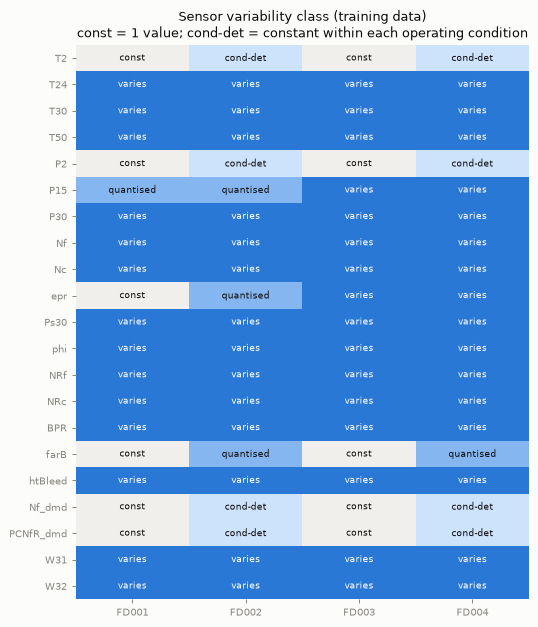

In [14]:
CAT_ORDER = ["constant", "condition-determined", "near-constant / quantised", "varies within condition"]
CAT_COLORS = ["#f0efec", "#cde2fb", "#86b6ef", "#2a78d6"]
CAT_SHORT = {"constant": "const", "condition-determined": "cond-det", "near-constant / quantised": "quantised",
             "varies within condition": "varies"}
codes = category_table.loc[SENSOR_COLUMNS].replace({c: i for i, c in enumerate(CAT_ORDER)}).astype(int)

fig, ax = plt.subplots(figsize=(6.5, 8))
ax.imshow(codes.to_numpy(), cmap=ListedColormap(CAT_COLORS), vmin=-0.5, vmax=3.5, aspect="auto")
for i in range(codes.shape[0]):
    for j in range(codes.shape[1]):
        k = codes.iat[i, j]
        ax.text(j, i, CAT_SHORT[CAT_ORDER[k]], ha="center", va="center", fontsize=7.5, color="#ffffff" if k == 3 else INK)
ax.set_xticks(range(len(SUBSETS)), SUBSETS)
ax.set_yticks(range(len(codes)), codes.index)
ax.grid(False)
ax.set_title("Sensor variability class (training data)\nconst = 1 value; cond-det = constant within each operating condition")
for sp in ax.spines.values():
    sp.set_visible(False)
savefig(fig, "04_feature_variability_class")
plt.show()

In [15]:
# Share of raw sensor variance explained by the operating condition (eta^2) in the multi-condition subsets.
eta = pd.DataFrame({s: profiles[s].loc[SENSOR_COLUMNS, "eta2_condition"].astype(float) for s in ["FD002", "FD004"]}).round(4)
eta

,FD002,FD004
T2,1.0000,1.0000
T24,0.9999,0.9998
T30,0.9971,0.9963
T50,0.9957,0.9944
P2,1.0000,1.0000
P15,1.0000,1.0000
P30,1.0000,0.9998
Nf,1.0000,1.0000
Nc,0.9973,0.9972
epr,0.9998,0.9983


**Result.**
- **FD001 / FD003 (one condition):** `T2`, `P2`, `farB`, `Nf_dmd`, `PCNfR_dmd` are constant, and so is `epr` in FD001. The operating settings are their condition centre plus < 0.01 noise (`op_setting_3` is exactly 100). `P15` has only 2 distinct values in FD001. In FD003 `epr` has 4 levels and changes in only some engines (Section 10.5 shows why this matters).
- **FD002 / FD004 (six conditions):** `T2`, `P2`, `Nf_dmd` and `PCNfR_dmd` vary a lot in raw form but are **constant within every condition**, so they encode the flight condition, not engine health. `op_setting_3` is condition-determined too. `epr` and `farB` take only 1-6 levels per condition (0.01 resolution), and `P15` is quantised to a few levels per condition.
- For the remaining raw sensors in FD002/FD004, the operating condition explains **~99%+ of the variance** (η²). Any raw-scale statistic (distribution, correlation, trend) in these subsets is dominated by the operating condition, so condition normalisation is a prerequisite for every analysis below.
- `htBleed` is integer-valued (10-54 levels). It is quantised but still carries a trend (Section 9).

## 5. Engine counts, cycles per engine, lifespans

In [16]:
life = []
for s in SUBSETS:
    for sp in ("train", "test"):
        L = data[s][sp].groupby("unit_id")["cycle"].max()
        life.append(pd.Series(L.values, name="cycles").to_frame().assign(subset=s, split=sp))
life = pd.concat(life, ignore_index=True)
life_stats = life.groupby(["subset", "split"])["cycles"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1)
savetab(life_stats, "cycles_per_engine")
life_stats

saved reports\tables\eda\cycles_per_engine.csv


count   mean   std    min     5%    25%    50%    75%    95%    max
subset split                                                                     
FD001  test   100.0  131.0  53.6   31.0   47.9   88.8  133.5  164.2  213.2  303.0
       train  100.0  206.3  46.3  128.0  147.0  177.0  199.0  229.2  287.3  362.0
FD002  test   259.0  131.2  63.1   21.0   40.0   76.5  132.0  168.0  245.2  367.0
       train  260.0  206.8  46.8  128.0  148.0  174.0  199.0  230.2  297.1  378.0
FD003  test   100.0  166.0  86.9   38.0   56.0  105.0  148.0  208.0  334.2  475.0
       train  100.0  247.2  86.5  145.0  157.9  189.8  220.5  279.8  447.6  525.0
FD004  test   248.0  166.2  91.6   19.0   35.1  102.0  153.5  218.5  346.9  486.0
       train  249.0  246.0  73.1  128.0  151.4  190.0  234.0  290.0  379.0  543.0

saved reports\figures\eda\05_cycles_per_engine.png


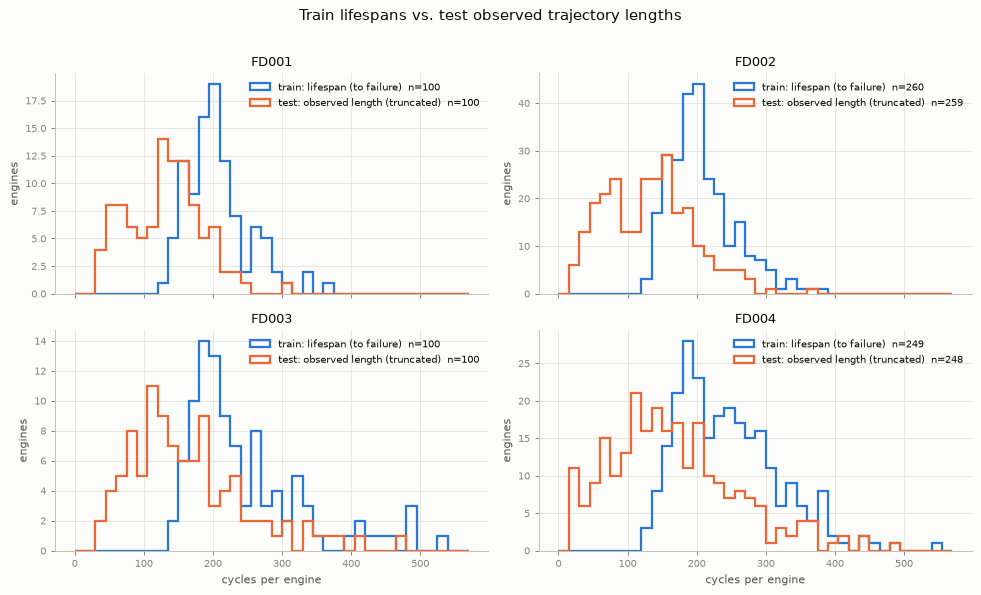

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
bins = np.arange(0, 575, 15)
for ax, s in zip(axes.flat, SUBSETS):
    for sp in ("train", "test"):
        v = life.query("subset == @s and split == @sp")["cycles"]
        ax.hist(v, bins=bins, histtype="step", lw=1.8, color=SPLIT_COLORS[sp],
                label=f"{sp}: {'lifespan (to failure)' if sp == 'train' else 'observed length (truncated)'}  n={len(v)}")
    ax.set_title(s)
    ax.set_ylabel("engines")
    ax.legend(loc="upper right")
for ax in axes[1]:
    ax.set_xlabel("cycles per engine")
fig.suptitle("Train lifespans vs. test observed trajectory lengths", y=1.01)
fig.tight_layout()
savefig(fig, "05_cycles_per_engine")
plt.show()

**Result.** Training lifespans are right-skewed, with a minimum of 128 cycles in FD001/FD002/FD004 and 145 in FD003. Medians are ~199 cycles for FD001/FD002 and longer for the two-fault-mode subsets (FD003 ~220, FD004 ~234). The maxima are 362 / 378 / 525 / 543 cycles. Test trajectories are truncated before failure, so they are much shorter: the shortest test units have **31 / 21 / 38 / 19** cycles.

## 6. Operating settings and operating conditions

In [18]:
# The three settings sit on a few exact centres plus tiny noise; check that rounding recovers them
# with no ambiguity (assign_operating_condition raises if any row matches no centre).
dev_rows = {}
for s in SUBSETS:
    for sp in ("train", "test"):
        df = data[s][sp]
        centres = np.array(OPERATING_CONDITIONS)[df["op_condition"].to_numpy()]
        dev = np.abs(df[SETTING_COLUMNS].to_numpy() - centres).max(axis=0)
        dev_rows[f"{s} {sp}"] = dict(zip([f"max |dev| {c}" for c in SETTING_COLUMNS], dev)) | {
            "n_conditions": df["op_condition"].nunique()}
pd.DataFrame(dev_rows).T

,max |dev| op_setting_1,max |dev| op_setting_2,max |dev| op_setting_3,n_conditions
FD001 train,0.0087,0.0006,0.0,1.0
FD001 test,0.0082,0.0007,0.0,1.0
FD002 train,0.0080,0.0020,0.0,6.0
FD002 test,0.0080,0.0020,0.0,6.0
FD003 train,0.0086,0.0007,0.0,1.0
FD003 test,0.0087,0.0006,0.0,1.0
FD004 train,0.0080,0.0020,0.0,6.0
FD004 test,0.0080,0.0020,0.0,6.0


In [19]:
cond_freq = pd.concat({f"{s} {sp}": data[s][sp]["op_condition"].value_counts(normalize=True).sort_index()
                       for s in ["FD002", "FD004"] for sp in ("train", "test")}, axis=1).round(3)
cond_freq.index = [f"{i}: {OPERATING_CONDITIONS[i]}" for i in cond_freq.index]
savetab(cond_freq, "operating_condition_frequencies")
cond_freq

saved reports\tables\eda\operating_condition_frequencies.csv


,FD002 train,FD002 test,FD004 train,FD004 test
"0: (0.0, 0.0, 100.0)",0.150,0.151,0.151,0.147
"1: (10.0, 0.25, 100.0)",0.151,0.150,0.151,0.150
"2: (20.0, 0.7, 100.0)",0.151,0.149,0.148,0.152
"3: (25.0, 0.62, 60.0)",0.149,0.148,0.149,0.148
"4: (35.0, 0.84, 100.0)",0.150,0.151,0.150,0.151
"5: (42.0, 0.84, 100.0)",0.250,0.250,0.251,0.252


saved reports\figures\eda\06_operating_settings.png


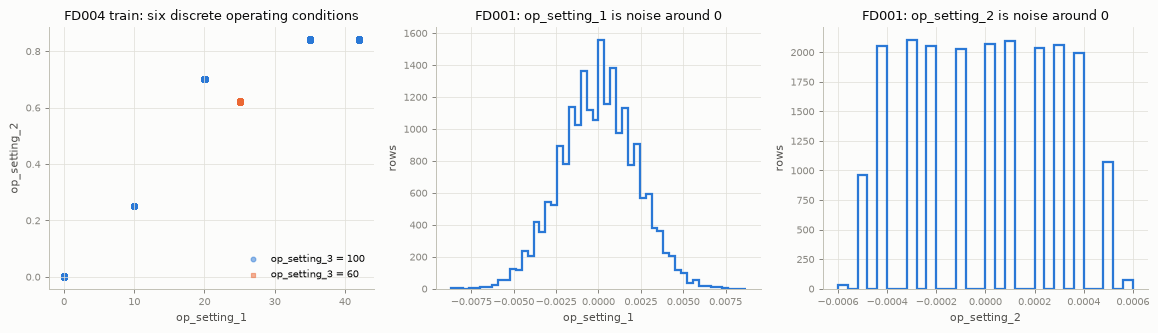

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
df = data["FD004"]["train"]
for tra, marker in [(100.0, "o"), (60.0, "s")]:
    sub = df[df.op_setting_3 == tra]
    axes[0].scatter(sub.op_setting_1, sub.op_setting_2, s=14, marker=marker, color="#2a78d6" if tra == 100 else "#eb6834",
                    alpha=0.5, label=f"op_setting_3 = {tra:g}")
axes[0].set(xlabel="op_setting_1", ylabel="op_setting_2", title="FD004 train: six discrete operating conditions")
axes[0].legend(loc="lower right")
df1 = data["FD001"]["train"]
axes[1].hist(df1.op_setting_1, bins=50, color=FD_COLORS["FD001"], histtype="step", lw=1.8)
axes[1].set(title="FD001: op_setting_1 is noise around 0", xlabel="op_setting_1", ylabel="rows")
axes[2].hist(df1.op_setting_2, bins=30, color=FD_COLORS["FD001"], histtype="step", lw=1.8)
axes[2].set(title="FD001: op_setting_2 is noise around 0", xlabel="op_setting_2", ylabel="rows")
fig.tight_layout()
savefig(fig, "06_operating_settings")
plt.show()

In [21]:
# Does the condition persist from one cycle to the next, or is it re-drawn every cycle?
rows = {}
for s in ["FD002", "FD004"]:
    df = data[s]["train"]
    same = (df.groupby("unit_id")["op_condition"].diff().dropna() == 0).mean()
    p = df["op_condition"].value_counts(normalize=True)
    rows[s] = {"P(condition_t == condition_t-1)": round(same, 3), "expected if independent (sum p^2)": round((p ** 2).sum(), 3)}
pd.DataFrame(rows).T

,P(condition_t == condition_t-1),expected if independent (sum p^2)
FD002,0.175,0.175
FD004,0.174,0.175


**Result.**
- FD001/FD003 run at a single condition, (0, 0, 100). The settings deviate from their centre by < 0.01, so their tiny variations are measurement noise, not a degradation signal.
- FD002/FD004 use **six discrete conditions**. Rounding to (0, 2, 0) decimals assigns every row of every file unambiguously, with max deviation < 0.01. This is deterministic and needs no fitting (no clustering), so it can be applied identically to train and test without leakage.
- Condition frequencies are almost identical in train and test (~25% for condition 5, ~15% for each of the others).
- The condition is **re-drawn independently every cycle**: the chance of the same condition in consecutive cycles equals the independence baseline. Raw sensor series in FD002/FD004 therefore jump between six levels from cycle to cycle. Smoothing, rolling features or sequence models applied to raw values would mostly learn condition switching, so **normalise per condition before any temporal feature**.

## 7. Sensor distributions (raw)

saved reports\figures\eda\07_sensor_distributions_raw.png


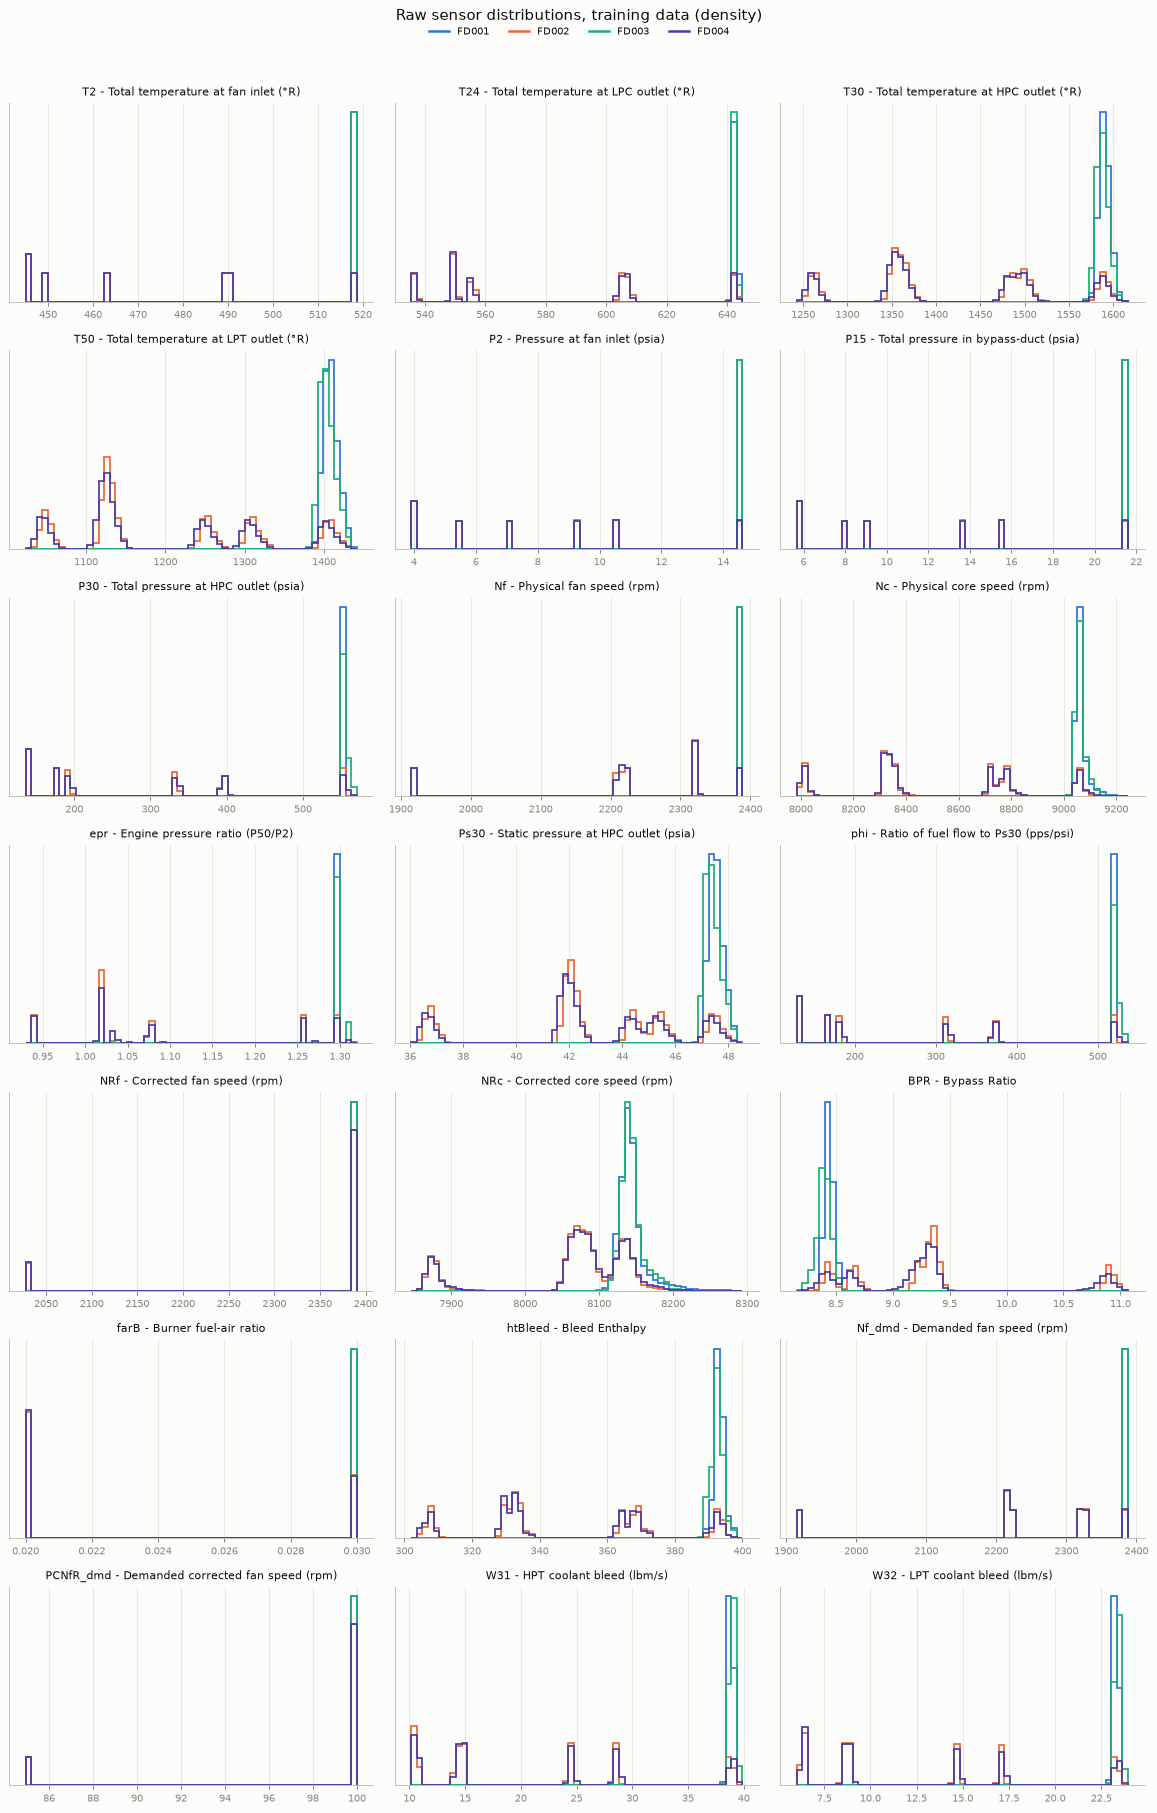

In [22]:
fig, axes = plt.subplots(7, 3, figsize=(13, 20))
for ax, c in zip(axes.flat, SENSOR_COLUMNS):
    lo = min(data[s]["train"][c].min() for s in SUBSETS)
    hi = max(data[s]["train"][c].max() for s in SUBSETS)
    b = np.linspace(lo, hi, 60) if hi > lo else 10
    for s in SUBSETS:
        ax.hist(data[s]["train"][c], bins=b, density=True, histtype="step", lw=1.4, color=FD_COLORS[s])
    sen = SENSOR_BY_SYMBOL[c]
    ax.set_title(f"{c} - {sen.description}" + ("" if sen.units == "--" else f" ({sen.units})"), fontsize=8.5)
    ax.set_yticks([])
fd_legend(fig)
fig.suptitle("Raw sensor distributions, training data (density)", y=1.005)
fig.tight_layout(rect=(0, 0, 1, 0.985))
savefig(fig, "07_sensor_distributions_raw")
plt.show()

**Result.** FD001 and FD003 (single condition) give narrow, unimodal distributions. FD002 and FD004 are **multi-modal, with one mode per operating condition**, and span ranges 10-100× wider. The multi-condition subsets also cover the single-condition range (condition 0 = sea level), so FD001/FD003 lie inside the FD002/FD004 support. A model trained on raw values from one family will not transfer to the other without condition normalisation.

### 7.1 Condition-normalised distributions

Each sensor is z-scored within its operating condition using **training-only** statistics, separately per subset.

sensors varying within condition in at least one subset: ['T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'W31', 'W32']


saved reports\figures\eda\07_sensor_distributions_condition_normalised.png


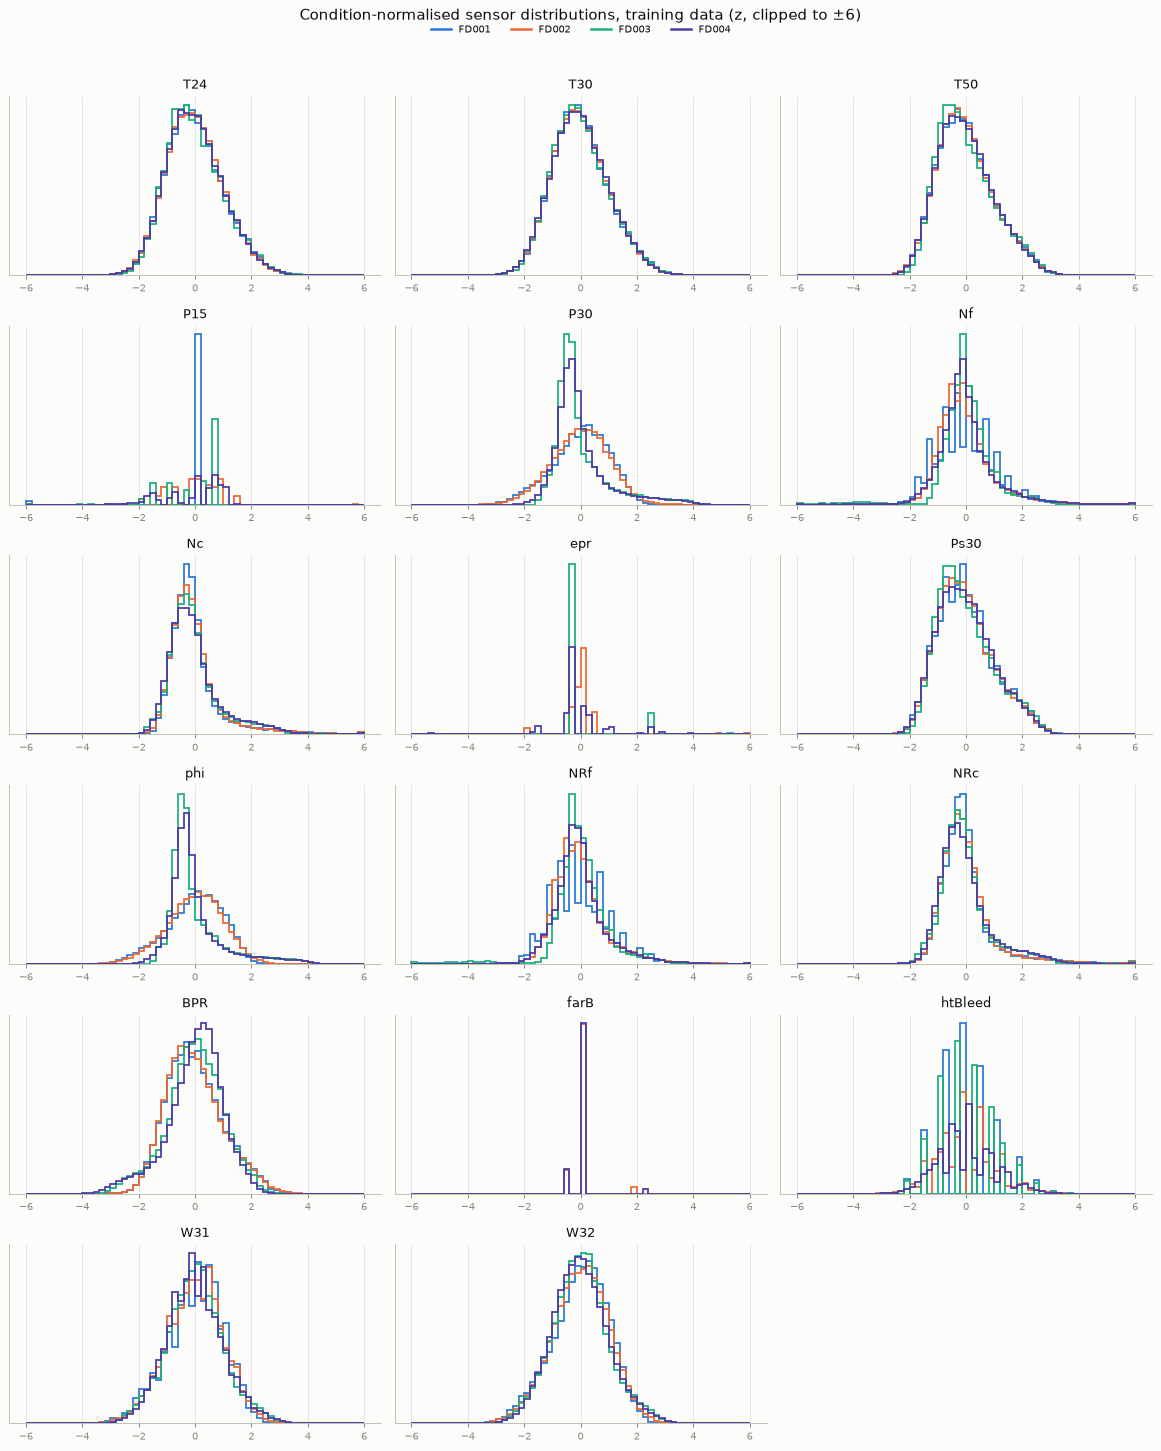

In [23]:
cond_stats = {s: fit_condition_stats(data[s]["train"]) for s in SUBSETS}
norm = {s: {sp: apply_condition_norm(data[s][sp], cond_stats[s]) for sp in ("train", "test")} for s in SUBSETS}

VARYING = {s: [c for c in SENSOR_COLUMNS if profiles[s].loc[c, "category"] not in ("constant", "condition-determined")] for s in SUBSETS}
ALL_VARYING = [c for c in SENSOR_COLUMNS if any(c in VARYING[s] for s in SUBSETS)]
print("sensors varying within condition in at least one subset:", ALL_VARYING)

fig, axes = plt.subplots(6, 3, figsize=(13, 16))
for ax, c in zip(axes.flat, ALL_VARYING):
    for s in SUBSETS:
        if c in VARYING[s]:
            ax.hist(norm[s]["train"][c].clip(-6, 6), bins=np.linspace(-6, 6, 61), density=True, histtype="step", lw=1.4, color=FD_COLORS[s])
    ax.set_title(c)
    ax.set_yticks([])
for ax in axes.flat[len(ALL_VARYING):]:
    ax.set_visible(False)
fd_legend(fig)
fig.suptitle("Condition-normalised sensor distributions, training data (z, clipped to ±6)", y=1.005)
fig.tight_layout(rect=(0, 0, 1, 0.985))
savefig(fig, "07_sensor_distributions_condition_normalised")
plt.show()

In [24]:
skew = pd.DataFrame({s: norm[s]["train"][VARYING[s]].skew() for s in SUBSETS}).round(2)
skew

,FD001,FD002,FD003,FD004
BPR,0.39,0.45,-0.31,-0.66
NRc,2.37,2.28,1.86,1.63
NRf,0.47,1.72,-1.35,1.12
Nc,2.56,2.41,1.90,1.65
Nf,0.48,1.71,-1.36,1.13
P15,-6.92,-0.56,-1.68,-0.84
P30,-0.39,-0.18,1.80,1.67
Ps30,0.47,0.51,0.63,0.42
T24,0.32,0.26,0.45,0.31
T30,0.31,0.27,0.35,0.25


**Result.** After condition normalisation, the four subsets lie on a common scale.
- The degrading sensors are mildly skewed in the direction of degradation (skew ≈ +0.3 to +0.6 for rising sensors such as `T50` and `Ps30`, slightly negative for `P30`/`phi`/`W31`/`W32` in FD001/FD002). Most of each trajectory is near-healthy, and the tail comes from the final degradation phase.
- `Nc`/`NRc` are strongly right-skewed (≈ 1.6-2.6), with a long upper tail late in life.
- In FD003/FD004, `P30`, `phi`, `W31`, `W32` switch from negative to positive skew, and `BPR` from positive to negative. This is the first sign of a second fault mode moving these sensors the *opposite* way (Section 10.5).
- `epr`, `farB` and `P15` remain visibly discrete, with extreme skew values driven by a few rare levels.

## 8. Sensor variance

In [25]:
var_rows = []
for s in SUBSETS:
    p = profiles[s]
    for c in SENSOR_COLUMNS:
        mean_abs = data[s]["train"][c].abs().mean()
        var_rows.append({"subset": s, "sensor": c, "raw_std": p.loc[c, "std"],
                         "within_condition_std": p.loc[c, "mean_std_within_condition"],
                         "within_condition_cv": p.loc[c, "mean_std_within_condition"] / mean_abs if mean_abs else np.nan,
                         "eta2_condition": p.loc[c, "eta2_condition"]})
variance = pd.DataFrame(var_rows)
savetab(variance, "sensor_variance", index=False)
variance.pivot(index="sensor", columns="subset", values="within_condition_cv").loc[SENSOR_COLUMNS].map(lambda v: f"{v:.2e}")

saved reports\tables\eda\sensor_variance.csv


subset,FD001,FD002,FD003,FD004
sensor,,,,
T2,0.00e+00,0.00e+00,0.00e+00,0.00e+00
T24,7.78e-04,7.66e-04,8.14e-04,8.27e-04
T30,3.85e-03,4.01e-03,4.29e-03,4.55e-03
T50,6.39e-03,6.50e-03,6.96e-03,7.37e-03
P2,0.00e+00,0.00e+00,0.00e+00,0.00e+00
P15,6.43e-05,3.09e-04,8.39e-04,1.28e-03
P30,1.60e-03,2.07e-03,6.19e-03,6.71e-03
Nf,2.97e-05,8.47e-05,6.63e-05,9.28e-05
Nc,2.44e-03,2.03e-03,2.20e-03,2.06e-03


saved reports\figures\eda\08_sensor_within_condition_cv.png


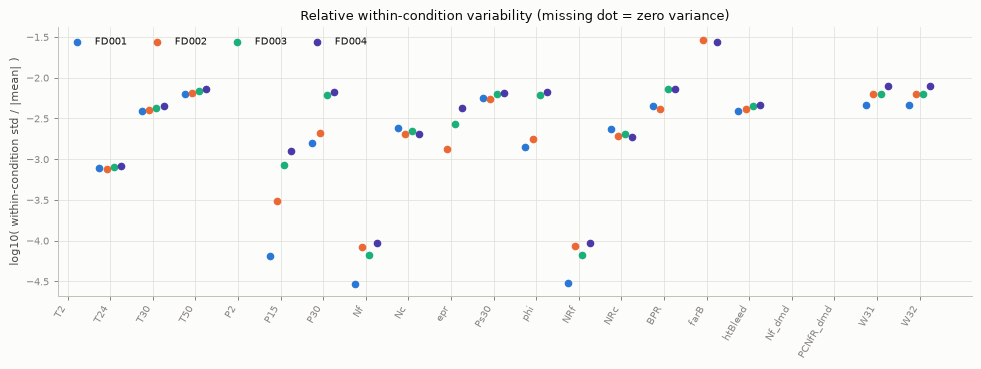

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(SENSOR_COLUMNS))
for k, s in enumerate(SUBSETS):
    v = variance.query("subset == @s").set_index("sensor").loc[SENSOR_COLUMNS, "within_condition_cv"].astype(float)
    ax.scatter(x + (k - 1.5) * 0.17, np.log10(v.where(v > 0)), s=26, color=FD_COLORS[s], label=s, zorder=3)
ax.set_xticks(x, SENSOR_COLUMNS, rotation=60, ha="right")
ax.set_ylabel("log10( within-condition std / |mean| )")
ax.set_title("Relative within-condition variability (missing dot = zero variance)")
ax.legend(ncol=4, loc="upper left")
fig.tight_layout()
savefig(fig, "08_sensor_within_condition_cv")
plt.show()

**Result.** Within-condition relative variability is tiny for every sensor (CV ≈ 10⁻⁵ to 10⁻²). Raw variance therefore says nothing about usefulness. `Nf`/`NRf`, for example, vary by only ~0.003% of their mean, yet they carry a clear degradation trend (Section 10). Low-variance thresholds such as `VarianceThreshold` on raw values must **not** be used for selection, except to drop exactly-constant columns. Usefulness has to be judged on trend and signal-to-noise.

## 9. Sensor correlations

saved reports\figures\eda\09_sensor_correlation_normalised.png


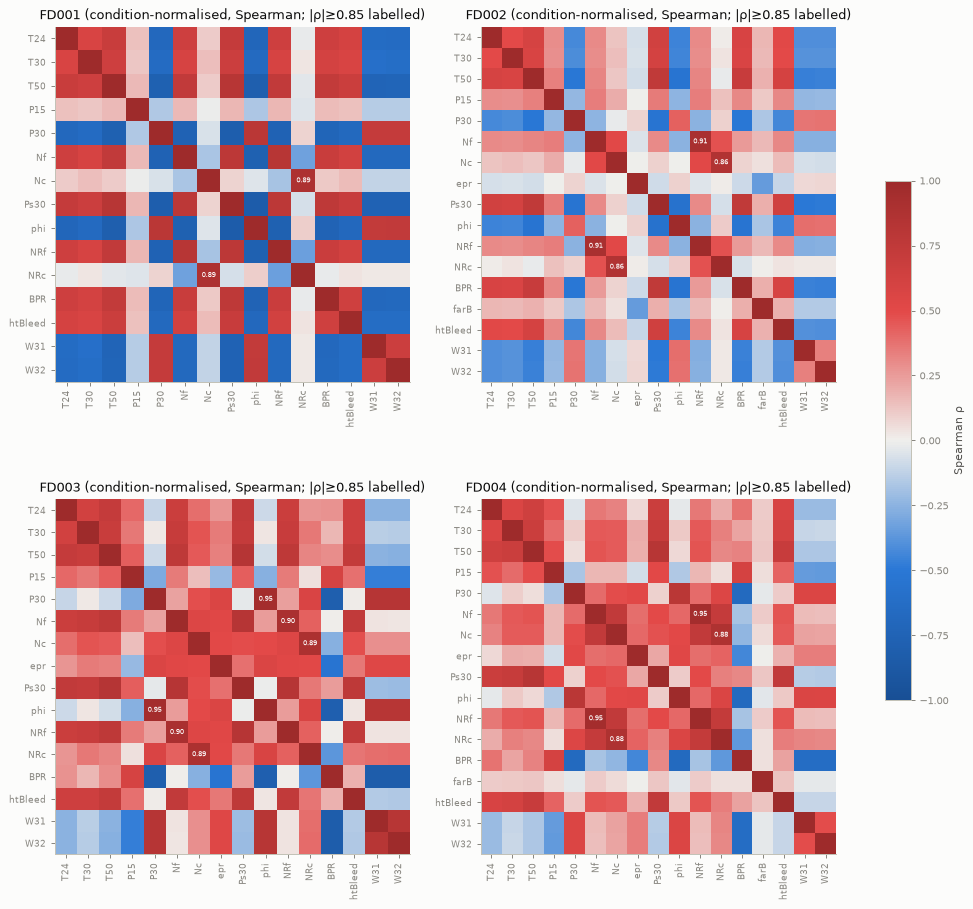

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12.5))
for ax, s in zip(axes.flat, SUBSETS):
    cols = VARYING[s]
    corr = norm[s]["train"][cols].corr(method="spearman")
    im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)), cols, rotation=90, fontsize=7.5)
    ax.set_yticks(range(len(cols)), cols, fontsize=7.5)
    ax.grid(False)
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i != j and abs(corr.iat[i, j]) >= 0.85:
                ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=5.5, color="#ffffff")
    ax.set_title(f"{s} (condition-normalised, Spearman; |ρ|≥0.85 labelled)")
fig.colorbar(im, ax=axes, shrink=0.6, label="Spearman ρ")
savefig(fig, "09_sensor_correlation_normalised")
plt.show()

In [28]:
# Highly correlated sensor pairs (|rho| >= 0.85) per subset, condition-normalised training data.
REDUNDANCY_THRESHOLD = 0.85
pairs = []
for s in SUBSETS:
    corr = norm[s]["train"][VARYING[s]].corr(method="spearman")
    for i, a in enumerate(corr.index):
        for b in corr.index[i + 1:]:
            if abs(corr.loc[a, b]) >= REDUNDANCY_THRESHOLD:
                pairs.append({"subset": s, "sensor_a": a, "sensor_b": b, "spearman": round(corr.loc[a, b], 3)})
pairs = pd.DataFrame(pairs)
savetab(pairs, "redundant_sensor_pairs", index=False)
pairs

saved reports\tables\eda\redundant_sensor_pairs.csv


,subset,sensor_a,sensor_b,spearman
0,FD001,Nc,NRc,0.886
1,FD002,Nf,NRf,0.908
2,FD002,Nc,NRc,0.858
3,FD003,P30,phi,0.950
4,FD003,Nf,NRf,0.905
5,FD003,Nc,NRc,0.892
6,FD004,Nf,NRf,0.951
7,FD004,Nc,NRc,0.882


In [29]:
# Physically related pairs, all subsets (condition-normalised Spearman rho).
phys_pairs = [("Nf", "NRf"), ("Nc", "NRc"), ("P30", "phi"), ("W31", "W32"), ("T30", "T50"), ("Ps30", "P30")]
pd.DataFrame({s: {f"{a} ~ {b}": norm[s]["train"][[a, b]].corr(method="spearman").iat[0, 1] for a, b in phys_pairs}
              for s in SUBSETS}).round(3)

,FD001,FD002,FD003,FD004
Nf ~ NRf,0.807,0.908,0.905,0.951
Nc ~ NRc,0.886,0.858,0.892,0.882
P30 ~ phi,0.794,0.425,0.950,0.794
W31 ~ W32,0.668,0.335,0.811,0.490
T30 ~ T50,0.651,0.578,0.689,0.672
Ps30 ~ P30,-0.806,-0.536,-0.030,0.088


In [30]:
# Raw-scale correlation in FD004 vs. condition-normalised: how much of the raw correlation is just the flight condition?
raw_corr = data["FD004"]["train"][VARYING["FD004"]].corr(method="spearman")
nrm_corr = norm["FD004"]["train"][VARYING["FD004"]].corr(method="spearman")
mask = ~np.eye(len(raw_corr), dtype=bool)
print(f"FD004 median |rho| between sensors: raw = {np.median(np.abs(raw_corr.to_numpy()[mask])):.2f}, "
      f"condition-normalised = {np.median(np.abs(nrm_corr.to_numpy()[mask])):.2f}")

FD004 median |rho| between sensors: raw = 0.84, condition-normalised = 0.34


**Result.**
- In raw FD004 data the median |ρ| between sensors is 0.84; after condition normalisation it is 0.34. Raw-scale correlation in the multi-condition subsets is mostly an artefact of the flight condition.
- Within condition, the strongest pairs are the physical/corrected speed pairs **`Nf`↔`NRf`** (ρ ≈ 0.81-0.95) and **`Nc`↔`NRc`** (ρ ≈ 0.86-0.89). This is expected, since `NRx` is `Nx` rescaled by an inlet temperature that is almost constant within a condition. In FD003, **`P30`↔`phi`** also reach 0.95. These pairs are candidates for de-duplication. They are *not* exact copies, though (ρ < 1, and the corrected speed also includes the inlet-temperature change), so the choice should be validated, not assumed.
- The degrading sensors form one correlated block (temperatures, `Ps30`, `BPR`, `htBleed` positive with each other, and negative with `P30`, `phi`, `W31`, `W32`). In FD003/FD004 this block is weaker and partly sign-mixed, because the two fault modes move some sensors in opposite directions.
- Moderate inter-sensor correlation is **not** a reason to drop a sensor. Averaging correlated noisy sensors improves signal-to-noise, so redundancy should be decided by validated model performance.

## 10. Sensor trends against cycle, and degradation behaviour

### 10.1 Example trajectories (seeded random units)

FD001 example units: [ 9 43 44 64 75 86]


saved reports\figures\eda\10_trends_fd001_examples.png


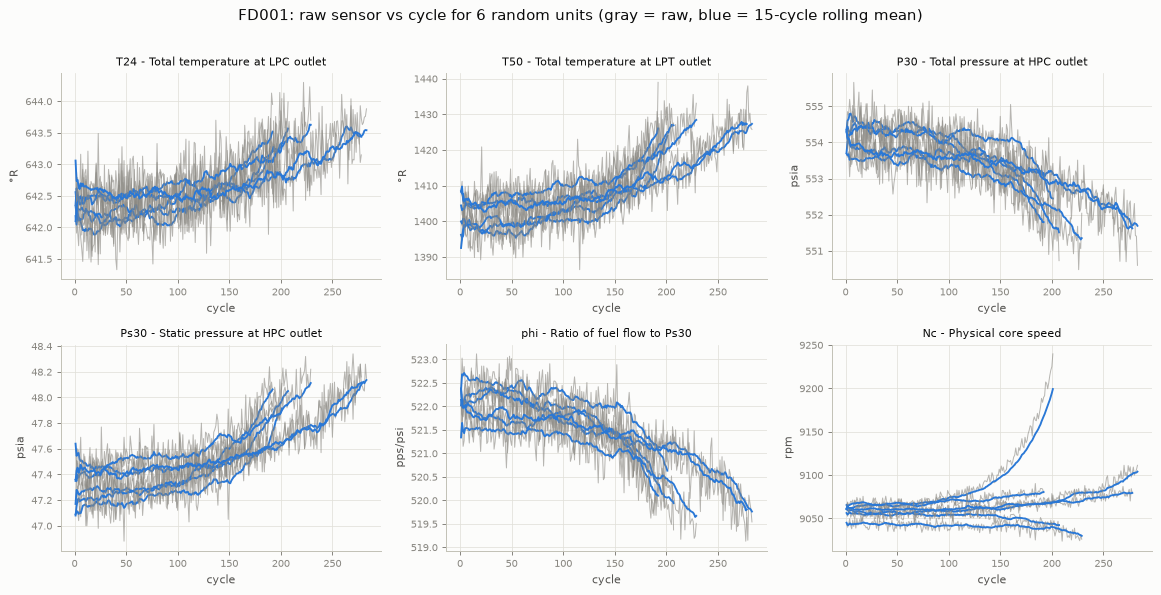

In [31]:
example_units = np.sort(rng.choice(data["FD001"]["train"].unit_id.unique(), size=6, replace=False))
print("FD001 example units:", example_units)
show = ["T24", "T50", "P30", "Ps30", "phi", "Nc"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
df = data["FD001"]["train"]
for ax, c in zip(axes.flat, show):
    for u in example_units:
        g = df[df.unit_id == u]
        ax.plot(g.cycle, g[c], color=NEUTRAL_LINE, lw=0.8, alpha=0.6)
        ax.plot(g.cycle, g[c].rolling(15, min_periods=1).mean(), color=FD_COLORS["FD001"], lw=1.5)
    sen = SENSOR_BY_SYMBOL[c]
    ax.set_title(f"{c} - {sen.description}", fontsize=9)
    ax.set_xlabel("cycle")
    ax.set_ylabel(sen.units if sen.units != "--" else "")
fig.suptitle("FD001: raw sensor vs cycle for 6 random units (gray = raw, blue = 15-cycle rolling mean)", y=1.01)
fig.tight_layout()
savefig(fig, "10_trends_fd001_examples")
plt.show()

FD004 example units: [183 190 241]


saved reports\figures\eda\10_trends_fd004_raw_vs_normalised.png


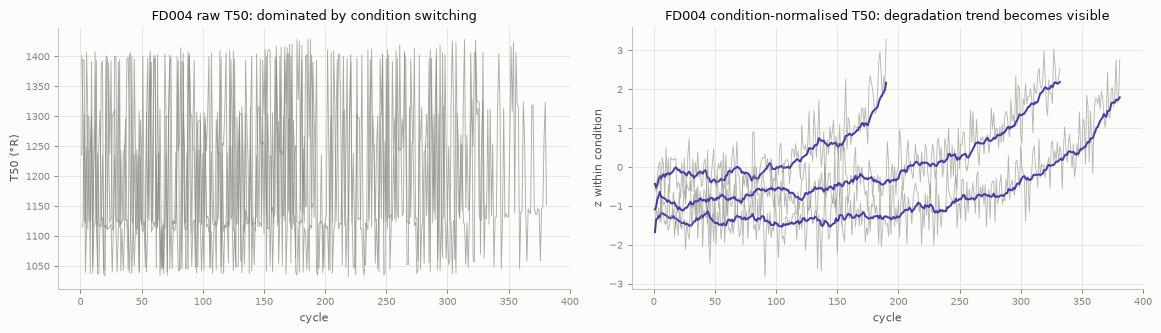

In [32]:
units4 = np.sort(rng.choice(data["FD004"]["train"].unit_id.unique(), size=3, replace=False))
print("FD004 example units:", units4)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for u in units4:
    g = data["FD004"]["train"].query("unit_id == @u")
    gn = norm["FD004"]["train"].query("unit_id == @u")
    axes[0].plot(g.cycle, g.T50, lw=0.7, color=NEUTRAL_LINE, alpha=0.7)
    axes[1].plot(gn.cycle, gn.T50, lw=0.7, color=NEUTRAL_LINE, alpha=0.6)
    axes[1].plot(gn.cycle, gn.T50.rolling(15, min_periods=1).mean(), lw=1.6, color=FD_COLORS["FD004"])
axes[0].set(title="FD004 raw T50: dominated by condition switching", xlabel="cycle", ylabel="T50 (°R)")
axes[1].set(title="FD004 condition-normalised T50: degradation trend becomes visible", xlabel="cycle", ylabel="z within condition")
fig.tight_layout()
savefig(fig, "10_trends_fd004_raw_vs_normalised")
plt.show()

### 10.2 Fleet-level degradation profile vs. cycles-to-failure

Median (line) and inter-quartile band of each condition-normalised sensor, aligned at failure (x = −RUL). Only RUL values with ≥ 10 contributing units are drawn.

saved reports\figures\eda\10_degradation_profiles_vs_rul.png


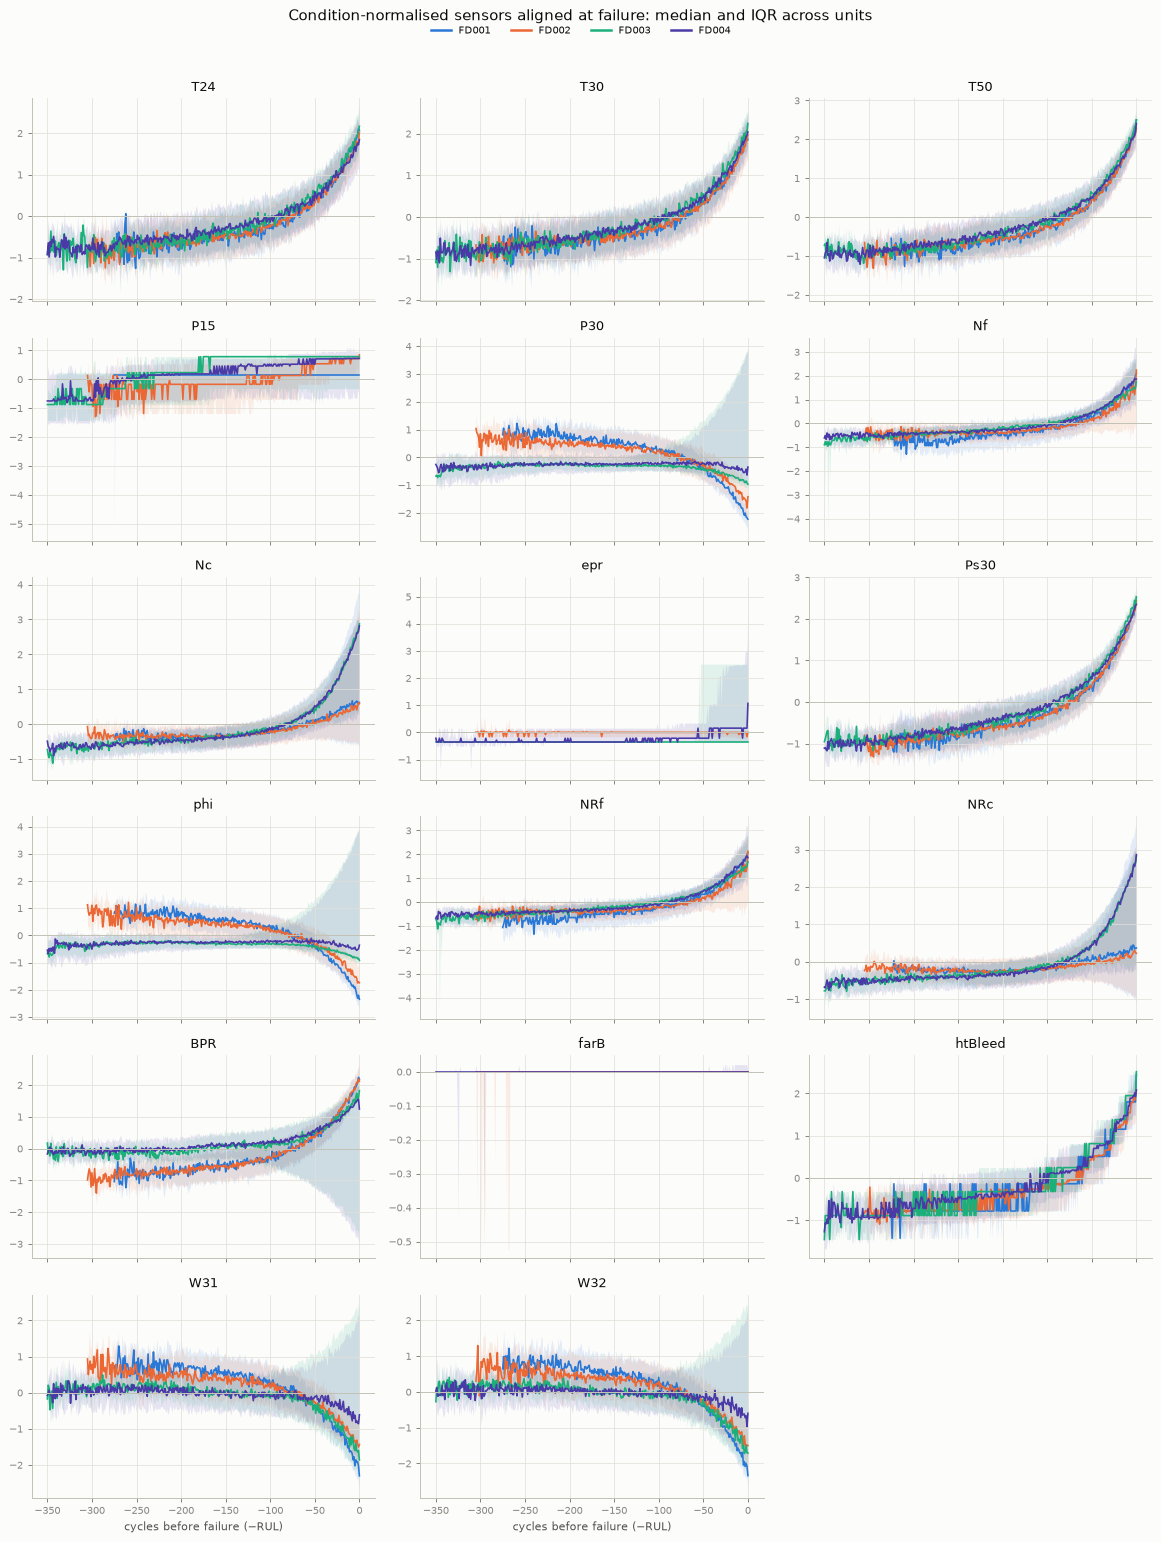

In [33]:
fig, axes = plt.subplots(6, 3, figsize=(13, 17), sharex=True)
for ax, c in zip(axes.flat, ALL_VARYING):
    for s in SUBSETS:
        if c not in VARYING[s]:
            continue
        df = norm[s]["train"].assign(RUL=data[s]["train"]["RUL"])
        g = df[df.RUL <= 350].groupby("RUL")[c]
        q = g.quantile([0.25, 0.5, 0.75]).unstack()
        q = q[g.size() >= 10]
        ax.fill_between(-q.index, q[0.25], q[0.75], color=FD_COLORS[s], alpha=0.12, lw=0)
        ax.plot(-q.index, q[0.5], color=FD_COLORS[s], lw=1.3)
    ax.set_title(c)
    ax.axhline(0, color=AXIS, lw=0.8)
for ax in axes.flat[len(ALL_VARYING):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("cycles before failure (−RUL)")
fd_legend(fig)
fig.suptitle("Condition-normalised sensors aligned at failure: median and IQR across units", y=1.005)
fig.tight_layout(rect=(0, 0, 1, 0.985))
savefig(fig, "10_degradation_profiles_vs_rul")
plt.show()

### 10.3 Within-unit monotonic trend: per-unit Spearman ρ(cycle, sensor)

The pooled correlation with RUL mixes units and fault modes. The per-unit trend measures whether a sensor moves consistently over *each* engine's life, and in which direction.

In [34]:
def unit_trends(df, cols):
    return df.groupby("unit_id")[cols + ["cycle"]].apply(lambda g: g[cols].corrwith(g["cycle"], method="spearman"))

trends = {s: unit_trends(norm[s]["train"], VARYING[s]) for s in SUBSETS}

trend_rows = []
for s in SUBSETS:
    t = trends[s]
    pooled = norm[s]["train"][VARYING[s]].corrwith(data[s]["train"]["RUL"], method="spearman")
    for c in VARYING[s]:
        v = t[c].dropna()  # NaN = sensor never changes within that unit
        trend_rows.append({"subset": s, "sensor": c,
                           "frac_units_with_variation": len(v) / len(t),
                           "pooled_spearman_vs_RUL": pooled[c],
                           "median_unit_rho": v.median(), "median_abs_unit_rho": v.abs().median(),
                           "frac_units_increasing": (v > 0).mean(),
                           "direction_consistency": max((v > 0).mean(), (v < 0).mean())})
trend_table = pd.DataFrame(trend_rows)
savetab(trend_table, "sensor_trend_metrics", index=False)
trend_table.pivot(index="sensor", columns="subset", values="frac_units_increasing").reindex(ALL_VARYING).round(2)

saved reports\tables\eda\sensor_trend_metrics.csv


subset,FD001,FD002,FD003,FD004
sensor,,,,
T24,1.00,1.00,1.00,1.00
T30,1.00,1.00,1.00,1.00
T50,1.00,1.00,1.00,1.00
P15,0.98,1.00,0.66,0.68
P30,0.00,0.00,0.44,0.41
Nf,1.00,0.83,1.00,0.85
Nc,0.71,0.73,0.84,0.85
epr,NaN,0.20,1.00,0.51
Ps30,1.00,1.00,1.00,1.00


saved reports\figures\eda\10_per_unit_trend_distribution.png


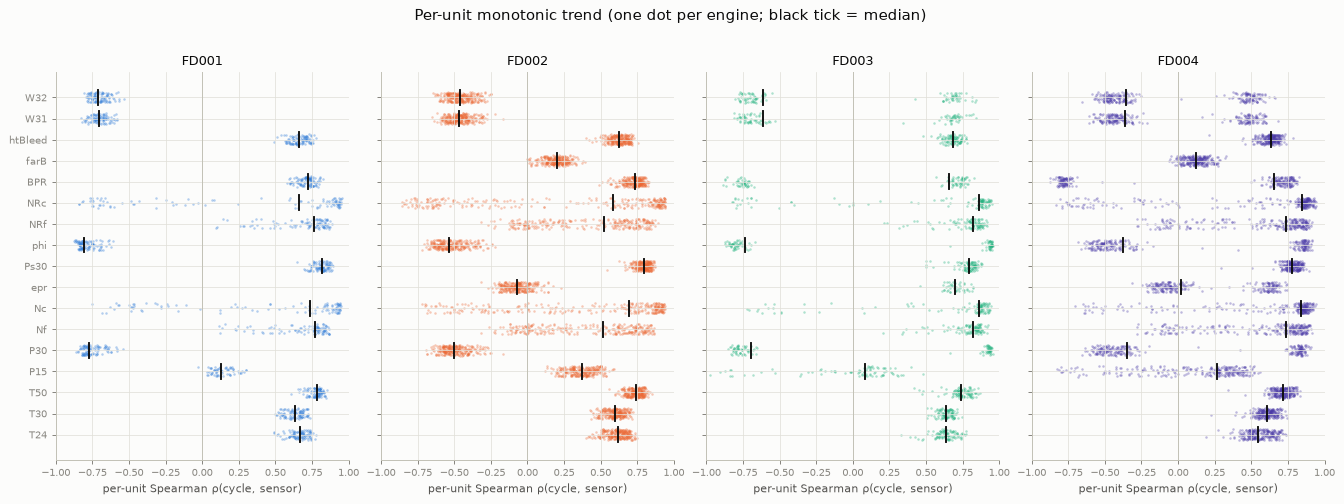

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5.5), sharey=True)
for ax, s in zip(axes, SUBSETS):
    t = trends[s].reindex(columns=ALL_VARYING)
    for i, c in enumerate(ALL_VARYING):
        v = t[c].dropna()
        if len(v):
            jitter = rng.uniform(-0.25, 0.25, len(v))
            ax.scatter(v, i + jitter, s=4, color=FD_COLORS[s], alpha=0.35, lw=0)
            ax.plot([v.median()] * 2, [i - 0.35, i + 0.35], color=INK, lw=1.5)
    ax.axvline(0, color=AXIS, lw=0.8)
    ax.set_yticks(range(len(ALL_VARYING)), ALL_VARYING)
    ax.invert_yaxis()
    ax.set_xlim(-1, 1)
    ax.set_title(s)
    ax.set_xlabel("per-unit Spearman ρ(cycle, sensor)")
fig.suptitle("Per-unit monotonic trend (one dot per engine; black tick = median)", y=1.01)
fig.tight_layout()
savefig(fig, "10_per_unit_trend_distribution")
plt.show()

### 10.4 Pooled correlation vs. within-unit trend: why correlation-based selection is risky

saved reports\figures\eda\10_pooled_vs_unit_correlation.png


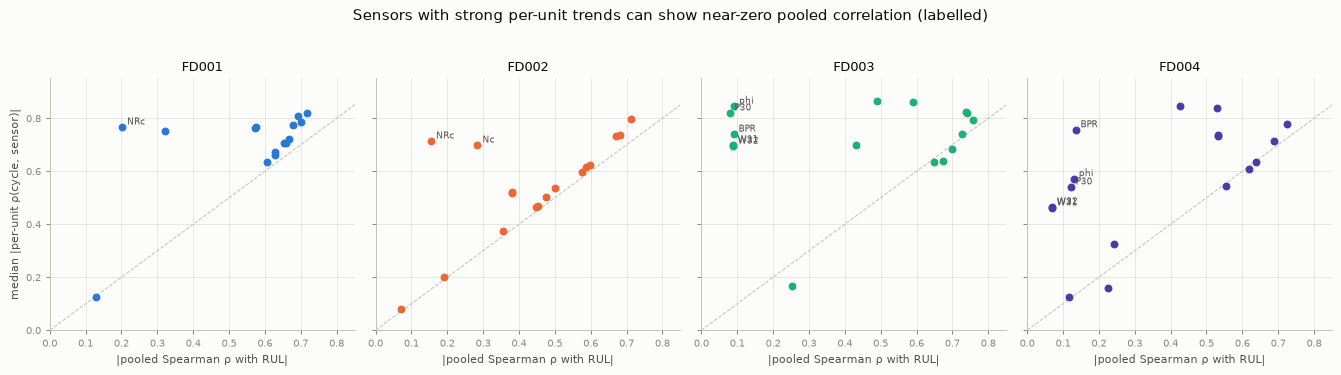

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
for ax, s in zip(axes, SUBSETS):
    t = trend_table.query("subset == @s")
    ax.scatter(t.pooled_spearman_vs_RUL.abs(), t.median_abs_unit_rho, s=28, color=FD_COLORS[s], zorder=3)
    for _, r in t.iterrows():
        if r.median_abs_unit_rho > 0.45 and abs(r.pooled_spearman_vs_RUL) < 0.3:
            ax.annotate(r.sensor, (abs(r.pooled_spearman_vs_RUL), r.median_abs_unit_rho), fontsize=7.5, color=INK2,
                        xytext=(4, 2), textcoords="offset points")
    ax.plot([0, 1], [0, 1], color=AXIS, lw=0.8, ls="--")
    ax.set(xlim=(0, 0.85), ylim=(0, 0.95), title=s, xlabel="|pooled Spearman ρ with RUL|")
axes[0].set_ylabel("median |per-unit ρ(cycle, sensor)|")
fig.suptitle("Sensors with strong per-unit trends can show near-zero pooled correlation (labelled)", y=1.03)
fig.tight_layout()
savefig(fig, "10_pooled_vs_unit_correlation")
plt.show()

### 10.5 Fault-mode signature: end-of-life change per unit

Per unit: Δ = mean of the last 20 cycles − mean of the first 20 cycles (condition-normalised). FD001/FD002 have one fault mode (HPC), FD003/FD004 have two (HPC + fan) according to the readme.

saved reports\figures\eda\10_fault_mode_signature.png


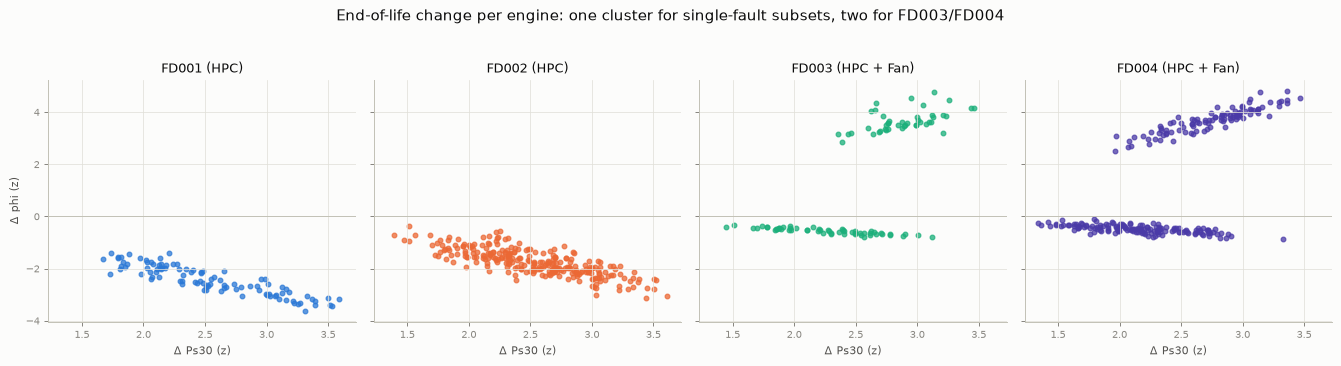

,units with Δphi < 0 (HPC-like),units with Δphi > 0
FD001,100,0
FD002,260,0
FD003,56,44
FD004,148,101


In [37]:
def eol_delta(df, cols, n=20):
    g = df.sort_values(["unit_id", "cycle"]).groupby("unit_id")
    return g[cols].apply(lambda x: x.tail(n).mean() - x.head(n).mean())

deltas = {s: eol_delta(norm[s]["train"], ["Ps30", "phi", "W31", "T50", "BPR"]) for s in SUBSETS}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9), sharex=True, sharey=True)
for ax, s in zip(axes, SUBSETS):
    d = deltas[s]
    ax.scatter(d.Ps30, d.phi, s=14, color=FD_COLORS[s], alpha=0.75)
    ax.axhline(0, color=AXIS, lw=0.8)
    ax.set(title=f"{s} ({SUBSET_INFO[s]['fault_modes']})", xlabel="Δ Ps30 (z)")
axes[0].set_ylabel("Δ phi (z)")
fig.suptitle("End-of-life change per engine: one cluster for single-fault subsets, two for FD003/FD004", y=1.03)
fig.tight_layout()
savefig(fig, "10_fault_mode_signature")
plt.show()

mode_split = pd.DataFrame({s: {"units with Δphi < 0 (HPC-like)": int((deltas[s].phi < 0).sum()),
                               "units with Δphi > 0": int((deltas[s].phi > 0).sum())} for s in SUBSETS}).T
mode_split

In [38]:
# Independent confirmation: epr (constant in FD001) changes only in some FD003/FD004 engines - which ones?
# Separation of the two engine groups per sensor (Cohen's d on the end-of-life change).
# Circular for phi itself (it defines the groups); informative for every other sensor.
def cohens_d(a, b):
    sp = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (b.mean() - a.mean()) / sp if sp > 0 else np.nan

mode_sep = {}
for s in ["FD003", "FD004"]:
    d_all = eol_delta(norm[s]["train"], VARYING[s])
    mode_b = d_all["phi"] > 0
    display(pd.crosstab(mode_b.rename(f"{s}: Δphi > 0"), (d_all["epr"] > 0.5).rename("Δepr > 0.5 z")))
    mode_sep[s] = {c: cohens_d(d_all.loc[~mode_b, c], d_all.loc[mode_b, c]) for c in VARYING[s]}
mode_sep = pd.DataFrame(mode_sep).round(2)
savetab(mode_sep, "fault_mode_separation_cohens_d")
mode_sep.sort_values("FD004", key=abs, ascending=False)

Δepr > 0.5 z,False,True
FD003: Δphi > 0,,
False,56,0
True,0,44


Δepr > 0.5 z,False,True
FD004: Δphi > 0,,
False,148,0
True,0,101


saved reports\tables\eda\fault_mode_separation_cohens_d.csv


,FD003,FD004
BPR,-11.92,-13.20
P30,14.74,13.00
phi,14.63,12.97
W31,11.59,9.85
W32,11.66,9.83
epr,14.22,9.57
P15,-0.42,-1.87
htBleed,1.88,1.83
T30,2.10,1.65
Nf,3.80,1.57


### 10.6 Degradation onset: simple health-indicator proxy

A rough, **EDA-only** proxy: the mean of the condition-normalised sensors that change in ≥ 80% of units and whose per-unit direction is consistent (≥ 95% of units) and strong (median |ρ| ≥ 0.5), with each sensor multiplied by the sign of its trend. It is used only to look at the *shape* of degradation (when it becomes visible), not as a model feature.

FD001 HI sensors: ['T24', 'T30', 'T50', 'P30', 'Nf', 'Ps30', 'phi', 'NRf', 'BPR', 'htBleed', 'W31', 'W32']
FD002 HI sensors: ['T24', 'T30', 'T50', 'P30', 'Ps30', 'phi', 'BPR', 'htBleed']
FD003 HI sensors: ['T24', 'T30', 'T50', 'Nf', 'Ps30', 'NRf', 'htBleed']
FD004 HI sensors: ['T24', 'T30', 'T50', 'Ps30', 'htBleed']


saved reports\figures\eda\10_health_indicator_onset.png


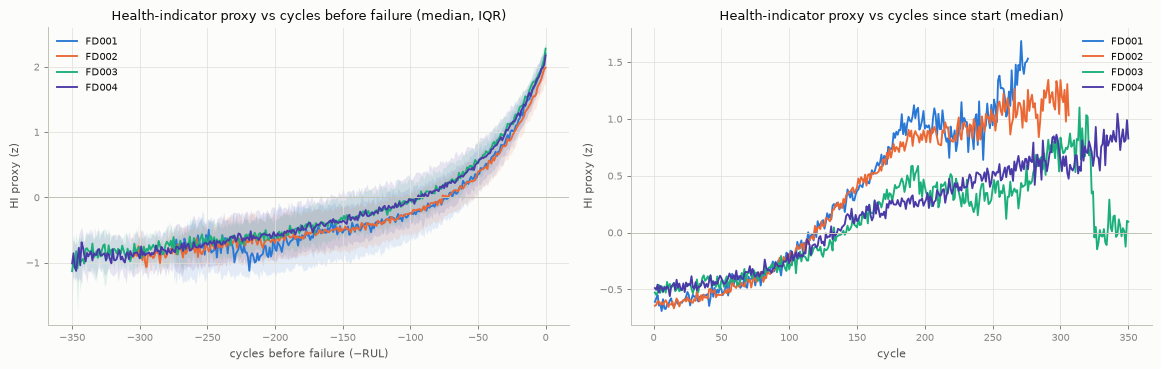

In [39]:
hi_sensors, hi = {}, {}
for s in SUBSETS:
    t = trend_table.query("subset == @s and frac_units_with_variation >= 0.8 and direction_consistency >= 0.95 and median_abs_unit_rho >= 0.5")
    hi_sensors[s] = dict(zip(t.sensor, np.sign(t.median_unit_rho)))
    z = norm[s]["train"]
    hi[s] = pd.DataFrame({"RUL": data[s]["train"]["RUL"], "cycle": z.cycle, "unit_id": z.unit_id,
                          "HI": sum(z[c] * sg for c, sg in hi_sensors[s].items()) / len(hi_sensors[s])})
    print(s, "HI sensors:", list(hi_sensors[s]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for s in SUBSETS:
    g = hi[s][hi[s].RUL <= 350].groupby("RUL")["HI"]
    q = g.quantile([0.25, 0.5, 0.75]).unstack()[g.size() >= 10]
    axes[0].fill_between(-q.index, q[0.25], q[0.75], color=FD_COLORS[s], alpha=0.12, lw=0)
    axes[0].plot(-q.index, q[0.5], color=FD_COLORS[s], label=s)
    g = hi[s][hi[s].cycle <= 350].groupby("cycle")["HI"]
    med = g.median()[g.size() >= 10]
    axes[1].plot(med.index, med, color=FD_COLORS[s], label=s)
axes[0].set(title="Health-indicator proxy vs cycles before failure (median, IQR)", xlabel="cycles before failure (−RUL)", ylabel="HI proxy (z)")
axes[1].set(title="Health-indicator proxy vs cycles since start (median)", xlabel="cycle", ylabel="HI proxy (z)")
for ax in axes:
    ax.axhline(0, color=AXIS, lw=0.8)
    ax.legend()
fig.tight_layout()
savefig(fig, "10_health_indicator_onset")
plt.show()

In [40]:
checkpoints = [250, 200, 150, 125, 100, 75, 50, 25, 0]
onset = pd.DataFrame({s: hi[s].groupby("RUL")["HI"].median().reindex(checkpoints) for s in SUBSETS}).round(2)
onset.index.name = "RUL"
savetab(onset, "health_indicator_median_at_rul")
onset

saved reports\tables\eda\health_indicator_median_at_rul.csv


,FD001,FD002,FD003,FD004
RUL,,,,
250,-0.68,-0.76,-0.71,-0.73
200,-0.78,-0.70,-0.60,-0.58
150,-0.54,-0.49,-0.34,-0.36
125,-0.38,-0.44,-0.20,-0.21
100,-0.24,-0.24,-0.01,-0.05
75,-0.02,0.00,0.20,0.14
50,0.35,0.39,0.52,0.53
25,1.03,0.92,1.14,1.13
0,2.20,1.99,2.28,2.17


**Temporal / degradation result.**
- **Noise vs. signal:** single-condition raw signals (FD001) show a clear trend under heavy noise. A single cycle is weakly informative, while 10-30-cycle windows reveal the trend.
- **Shape:** degradation is **non-linear**. Aligned at failure, the HI proxy drifts slowly for most of life (median ≈ −0.7 z at RUL 200-250) and then accelerates: +0.3 z between RUL 150 and 100, +0.6 z between 50 and 25, and +1.1 z in the last 25 cycles. This matches the paper's exponential fault-growth model. A **piecewise-linear (capped) RUL target** (constant early, linear near the end) is therefore physically motivated. Its cap (somewhere around 100-150 cycles) should be tuned by validation, not fixed by eye. The "vs cycle" panel is affected by survivorship (only long-lived engines contribute late cycles), but it shows the first ~50 cycles are near-flat in every subset, i.e. engines start healthy.
- **FD001 (HPC fault):** every engine shows the same directions. `T24`, `T30`, `T50`, `Ps30`, `BPR`, `htBleed`, `Nf`, `NRf` rise, and `P30`, `phi`, `W31`, `W32` fall. **FD002** follows the same directions, but `Nf`/`NRf` rise in only ~83% of engines, and `W31`/`W32` trends are weaker (median |ρ| ≈ 0.47 vs 0.71) because the six conditions add noise.
- **FD003/FD004 (HPC + fan faults): two engine groups.** In 44/100 (FD003) and 101/249 (FD004) engines, `P30`, `phi`, `W31`, `W32` **rise** instead of fall, `BPR` stays flat instead of rising, and `epr` (constant in FD001) **steps up**. The `epr` change matches the phi-direction grouping **exactly** (cross-tab above: 0 disagreements), and the group separation is huge (Cohen's |d| ≈ 10-15 for `P30`, `phi`, `BPR`, `W31`, `W32`, `epr`). The phi-falling group reproduces the FD001 HPC signature, so a reasonable *hypothesis* is that the other group is the fan-fault mode, consistent with a fan fault changing the engine pressure ratio. Fault-mode labels are not given in the data; this is inferred.
- These are the sensors whose *pooled* correlation with RUL in FD003/FD004 is near zero (|ρ| ≈ 0.07-0.14), while their within-unit trend is strong (median |ρ| ≈ 0.46-0.85). **A correlation filter would discard exactly the sensors that identify the fault mode.**
- `Nc`/`NRc` rise in most, but not all, engines even in FD001 (single fault), and they rise much more steeply near failure in FD003/FD004. Their behaviour is partly unit-dependent.

## 11. Differences between FD001, FD002, FD003 and FD004

In [41]:
fd_rows = {}
for s in SUBSETS:
    tr, te, rul = data[s]["train"], data[s]["test"], data[s]["rul"]
    Ltr = tr.groupby("unit_id").cycle.max()
    Lte = te.groupby("unit_id").cycle.max()
    cats = profiles[s].loc[SENSOR_COLUMNS, "category"]
    tt = trend_table.query("subset == @s")
    fd_rows[s] = {
        "operating conditions": tr.op_condition.nunique(),
        "fault modes (readme)": SUBSET_INFO[s]["fault_modes"],
        "train units / rows": f"{tr.unit_id.nunique()} / {len(tr)}",
        "test units / rows": f"{te.unit_id.nunique()} / {len(te)}",
        "train lifespan min/median/max": f"{Ltr.min()} / {Ltr.median():.0f} / {Ltr.max()}",
        "test length min/median/max": f"{Lte.min()} / {Lte.median():.0f} / {Lte.max()}",
        "test true RUL min/median/max": f"{rul.RUL.min()} / {rul.RUL.median():.0f} / {rul.RUL.max()}",
        "constant sensors": int((cats == "constant").sum()),
        "condition-determined sensors": int((cats == "condition-determined").sum()),
        "sensors with consistent trend (varies in ≥80% units, ≥95% same direction, |ρ|≥0.5)": int(((tt.frac_units_with_variation >= 0.8) & (tt.direction_consistency >= 0.95) & (tt.median_abs_unit_rho >= 0.5)).sum()),
        "sensors with mixed direction (<90% units, |ρ|≥0.5)": int(((tt.direction_consistency < 0.9) & (tt.median_abs_unit_rho >= 0.5)).sum()),
    }
fd_compare = pd.DataFrame(fd_rows)
savetab(fd_compare, "fd_subset_comparison")
fd_compare

saved reports\tables\eda\fd_subset_comparison.csv


,FD001,FD002,FD003,FD004
operating conditions,1,6,1,6
fault modes (readme),HPC,HPC,HPC + Fan,HPC + Fan
train units / rows,100 / 20631,260 / 53759,100 / 24720,249 / 61249
test units / rows,100 / 13096,259 / 33991,100 / 16596,248 / 41214
train lifespan min/median/max,128 / 199 / 362,128 / 199 / 378,145 / 220 / 525,128 / 234 / 543
test length min/median/max,31 / 134 / 303,21 / 132 / 367,38 / 148 / 475,19 / 154 / 486
test true RUL min/median/max,7 / 86 / 145,6 / 80 / 194,6 / 78 / 145,6 / 88 / 195
constant sensors,6,0,5,0
condition-determined sensors,0,4,0,4
"sensors with consistent trend (varies in ≥80% units, ≥95% same direction, |ρ|≥0.5)",12,8,7,5


**Result.** The subsets form a 2×2 design: {1, 6} operating conditions × {1, 2} fault modes.
- **Conditions** (FD002/FD004) mainly change the *scale* of every sensor, which normalisation removes, and they add discreteness through the condition-determined sensors.
- **Fault modes** (FD003/FD004) change the *direction* of several sensors, lengthen lifespans (medians ~220-234 vs ~199) and widen their spread (max 525-543 vs 362-378).
- FD004 is the hardest subset: it has both effects, the most units, the longest and most variable lives, and the shortest test trajectories (min 19 cycles).
- Pooling subsets for training is possible after per-condition normalisation, but the fault-mode mix differs between subsets. Evaluation must therefore stay **per subset**.

## 12. Train vs. test distribution comparison

Test trajectories stop before failure, so test rows are on average *earlier in life* than train rows. A naive train/test comparison therefore shows a shift that is just truncation. Three comparisons separate the two effects (two-sample KS statistic on condition-normalised sensors):
1. **all rows**: naive;
2. **first 20 cycles**: both near-healthy, which tests whether the engine *populations* (initial wear, noise) match;
3. **matched RUL band 50-125**: rows at the same remaining life, using the test RUL reconstructed from the RUL file (analysis only).

In [42]:
ks_rows = []
for s in SUBSETS:
    tr = norm[s]["train"].assign(RUL=data[s]["train"]["RUL"])
    te = norm[s]["test"].assign(RUL=data[s]["test"]["RUL"])
    for c in VARYING[s]:
        ks_rows.append({
            "subset": s, "sensor": c,
            "KS all rows": stats.ks_2samp(tr[c], te[c]).statistic,
            "KS first 20 cycles": stats.ks_2samp(tr.loc[tr.cycle <= 20, c], te.loc[te.cycle <= 20, c]).statistic,
            "KS RUL 50-125": stats.ks_2samp(tr.loc[tr.RUL.between(50, 125), c], te.loc[te.RUL.between(50, 125), c]).statistic,
        })
ks_table = pd.DataFrame(ks_rows)
savetab(ks_table, "train_test_ks", index=False)
ks_summary = ks_table.groupby("subset")[["KS all rows", "KS first 20 cycles", "KS RUL 50-125"]].median()

# 5% critical KS value with n = number of UNITS (rows within a unit are autocorrelated, so the
# row count would overstate the effective sample size; units are the conservative choice).
ks_summary["KS crit 5% (n = units)"] = [1.358 * np.sqrt(1 / data[s]["train"].unit_id.nunique() + 1 / data[s]["test"].unit_id.nunique())
                                        for s in ks_summary.index]
ks_summary.round(3)

saved reports\tables\eda\train_test_ks.csv


,KS all rows,KS first 20 cycles,KS RUL 50-125,KS crit 5% (n = units)
subset,,,,
FD001,0.181,0.057,0.087,0.192
FD002,0.102,0.032,0.011,0.119
FD003,0.148,0.049,0.065,0.192
FD004,0.132,0.028,0.059,0.122


saved reports\figures\eda\12_train_test_ks.png


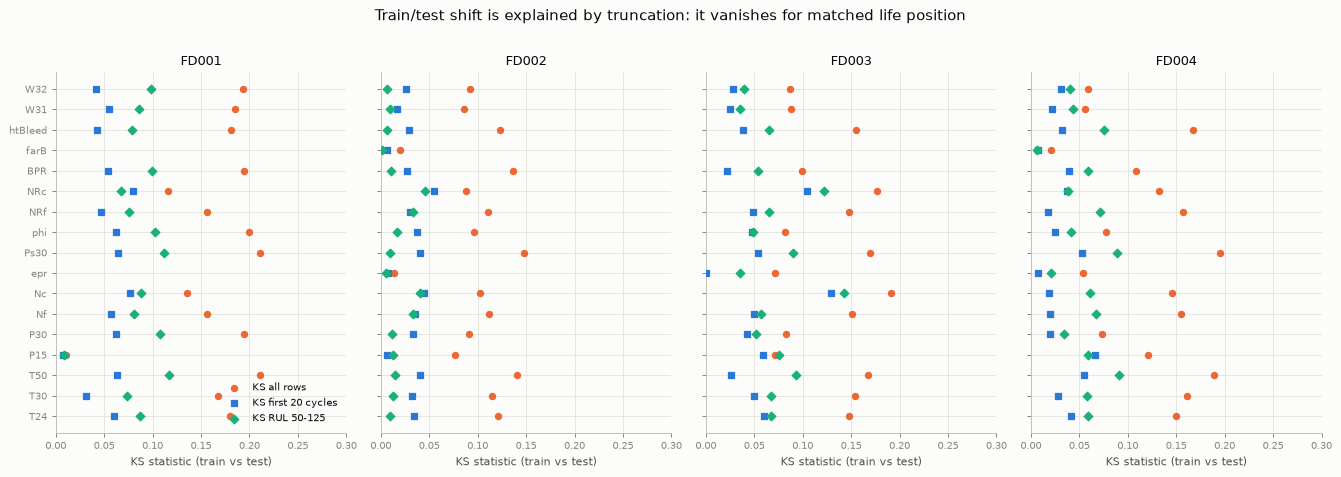

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5.2), sharey=True)
labels = ["KS all rows", "KS first 20 cycles", "KS RUL 50-125"]
marks = {"KS all rows": ("o", SPLIT_COLORS["test"]), "KS first 20 cycles": ("s", SPLIT_COLORS["train"]), "KS RUL 50-125": ("D", "#1baf7a")}
for ax, s in zip(axes, SUBSETS):
    t = ks_table.query("subset == @s").set_index("sensor").reindex(ALL_VARYING)
    y = np.arange(len(ALL_VARYING))
    for lab in labels:
        mk, col = marks[lab]
        ax.scatter(t[lab], y, marker=mk, s=24, color=col, label=lab, zorder=3)
    ax.set_yticks(y, ALL_VARYING)
    ax.invert_yaxis()
    ax.set(title=s, xlabel="KS statistic (train vs test)", xlim=(0, 0.3))
axes[0].legend(loc="lower right")
fig.suptitle("Train/test shift is explained by truncation: it vanishes for matched life position", y=1.01)
fig.tight_layout()
savefig(fig, "12_train_test_ks")
plt.show()

**Result.** On all rows the median KS statistic is 0.10-0.18, with up to ~0.2 for the strongly degrading sensors. For **matched** life positions it drops 2-10×: the median is 0.03-0.06 for the first 20 cycles and 0.01-0.09 for the RUL 50-125 band. All matched values are well below the unit-level 5% critical value (≈ 0.12-0.19). Train and test engines are consistent with coming from the **same population**, and the apparent shift is essentially the test-truncation effect. Operating-condition frequencies also match (Section 6). Implications:
- Any validation set carved out of the training data must **truncate trajectories the same way** the test set is truncated. Scoring every row of a full trajectory would over-represent the easy end-of-life rows.
- Scalers and normalisers fitted on training data apply correctly to test data.

## 13. RUL distributions

saved reports\figures\eda\13_rul_distributions.png


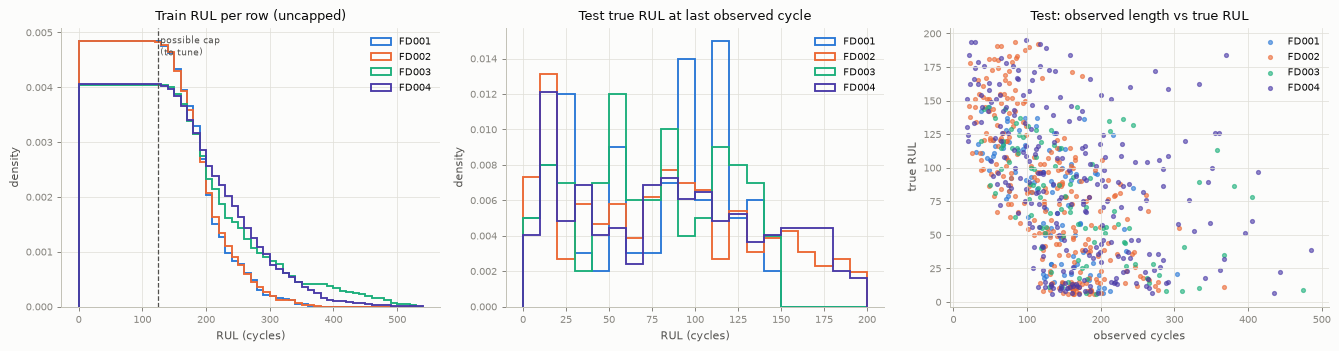

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for s in SUBSETS:
    axes[0].hist(data[s]["train"]["RUL"], bins=np.arange(0, 550, 10), density=True, histtype="step", lw=1.5, color=FD_COLORS[s], label=s)
    axes[1].hist(data[s]["rul"]["RUL"], bins=np.arange(0, 210, 10), density=True, histtype="step", lw=1.5, color=FD_COLORS[s], label=s)
    te_len = data[s]["test"].groupby("unit_id").cycle.max()
    axes[2].scatter(te_len.values, data[s]["rul"]["RUL"].values, s=10, alpha=0.6, color=FD_COLORS[s], label=s)
axes[0].axvline(125, color=INK2, lw=1, ls="--")
axes[0].text(128, axes[0].get_ylim()[1] * 0.9, "possible cap\n(to tune)", fontsize=7.5, color=INK2)
axes[0].set(title="Train RUL per row (uncapped)", xlabel="RUL (cycles)", ylabel="density")
axes[1].set(title="Test true RUL at last observed cycle", xlabel="RUL (cycles)", ylabel="density")
axes[2].set(title="Test: observed length vs true RUL", xlabel="observed cycles", ylabel="true RUL")
for ax in axes:
    ax.legend()
fig.tight_layout()
savefig(fig, "13_rul_distributions")
plt.show()

In [45]:
rul_stats = pd.concat({
    "train row RUL": pd.DataFrame({s: data[s]["train"]["RUL"].describe() for s in SUBSETS}),
    "test end RUL": pd.DataFrame({s: data[s]["rul"]["RUL"].describe() for s in SUBSETS}),
}).round(1)
implied = pd.DataFrame({s: (data[s]["test"].groupby("unit_id").cycle.max().values + data[s]["rul"]["RUL"].values) for s in SUBSETS}.items(),
                       columns=["subset", "v"]).set_index("subset")["v"].apply(lambda v: pd.Series(v).describe()).T.round(1)
savetab(rul_stats, "rul_statistics")
display(rul_stats)
print("Implied total life of test engines (observed length + true RUL):")
implied

saved reports\tables\eda\rul_statistics.csv


FD001    FD002    FD003    FD004
train row RUL count  20631.0  53759.0  24720.0  61249.0
              mean     107.8    108.2    138.1    133.3
              std       68.9     69.2     98.8     89.8
              min        0.0      0.0      0.0      0.0
              25%       51.0     51.0     61.0     61.0
              50%      103.0    103.0    123.0    122.0
              75%      155.0    156.0    190.0    190.0
              max      361.0    377.0    524.0    542.0
test end RUL  count    100.0    259.0    100.0    248.0
              mean      75.5     81.2     75.3     86.6
              std       41.8     53.9     41.6     54.6
              min        7.0      6.0      6.0      6.0
              25%       32.8     35.0     43.2     36.0
              50%       86.0     80.0     77.5     88.0
              75%      112.2    121.0    115.0    126.8
              max      145.0    194.0    145.0    195.0

Implied total life of test engines (observed length + true RUL):


subset,FD001,FD002,FD003,FD004
count,100.0,259.0,100.0,248.0
mean,206.5,212.4,241.3,252.7
std,44.0,47.8,76.0,85.1
min,141.0,126.0,137.0,126.0
25%,174.8,174.5,192.0,191.0
50%,199.0,204.0,222.5,235.0
75%,227.8,244.0,277.0,295.5
max,341.0,378.0,484.0,554.0


In [46]:
corr_len = pd.Series({s: np.corrcoef(data[s]["test"].groupby("unit_id").cycle.max().values, data[s]["rul"]["RUL"].values)[0, 1]
                      for s in SUBSETS}, name="corr(test observed length, true RUL)").round(3)
corr_len.to_frame()

,"corr(test observed length, true RUL)"
FD001,-0.598
FD002,-0.676
FD003,-0.484
FD004,-0.413


**Result.**
- Train row-level RUL is uniform-ish up to ~130 and then has a long right tail, up to 361-542. Most of that tail comes from early-life rows where the sensors are near-healthy (Section 10.6), so the raw RUL there is largely unpredictable from the sensors.
- Test end-RULs run from **6 to 145** (FD001/FD003) and **6 to 195** (FD002/FD004). The paper quotes 10-150 for the PHM08 challenge test set, so these public files differ from the challenge set described in the paper. The data files are taken as authoritative.
- The implied total life of the test engines (observed length + true RUL) matches the training lifespan distribution, which confirms the same engine population.
- **Observed test length is strongly anti-correlated with true RUL** (r ≈ −0.41 to −0.68). An engine observed for many cycles is, on average, closer to failure. Cycle count is therefore a real but *population-level* signal (age), not a health measurement. See the leakage section.

## 14. Short test trajectories

In [47]:
windows = [15, 20, 25, 30, 40, 50]
short = pd.DataFrame({s: {f"< {w} cycles": int((data[s]["test"].groupby("unit_id").cycle.max() < w).sum()) for w in windows}
                      for s in SUBSETS}).T
short["test units"] = [data[s]["test"].unit_id.nunique() for s in SUBSETS]
short["min length"] = [data[s]["test"].groupby("unit_id").cycle.max().min() for s in SUBSETS]
savetab(short, "short_test_trajectories")
short

saved reports\tables\eda\short_test_trajectories.csv


,< 15 cycles,< 20 cycles,< 25 cycles,< 30 cycles,< 40 cycles,< 50 cycles,test units,min length
FD001,0,0,0,0,4,7,100,31
FD002,0,0,3,6,12,24,259,21
FD003,0,0,0,0,1,3,100,38
FD004,0,2,7,11,16,20,248,19


saved reports\figures\eda\14_short_test_trajectories.png


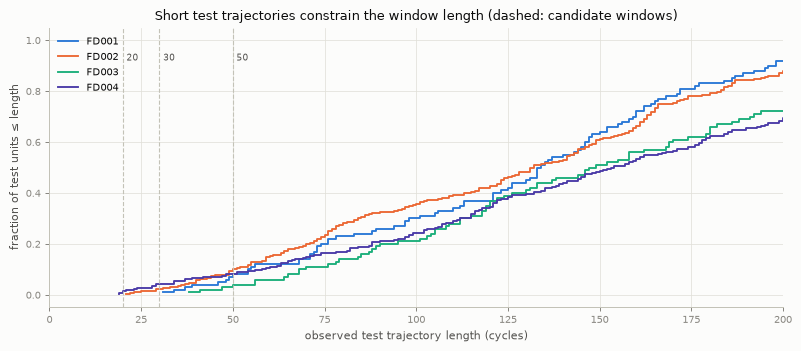

In [48]:
fig, ax = plt.subplots(figsize=(9, 4))
for s in SUBSETS:
    L = np.sort(data[s]["test"].groupby("unit_id").cycle.max().values)
    ax.step(L, np.arange(1, len(L) + 1) / len(L), where="post", color=FD_COLORS[s], label=s)
for w in [20, 30, 50]:
    ax.axvline(w, color=AXIS, lw=0.9, ls="--")
    ax.text(w + 1, 0.92, f"{w}", fontsize=7.5, color=INK2)
ax.set(xlim=(0, 200), xlabel="observed test trajectory length (cycles)", ylabel="fraction of test units ≤ length",
       title="Short test trajectories constrain the window length (dashed: candidate windows)")
ax.legend()
fig.tight_layout()
savefig(fig, "14_short_test_trajectories")
plt.show()

In [49]:
short_rul = pd.DataFrame({s: {
    "mean true RUL, units < 50 cycles": data[s]["rul"].set_index("unit_id").RUL[data[s]["test"].groupby("unit_id").cycle.max() < 50].mean(),
    "mean true RUL, units ≥ 50 cycles": data[s]["rul"].set_index("unit_id").RUL[data[s]["test"].groupby("unit_id").cycle.max() >= 50].mean(),
} for s in SUBSETS}).T.round(1)
short_rul

,"mean true RUL, units < 50 cycles","mean true RUL, units ≥ 50 cycles"
FD001,119.0,72.2
FD002,138.4,75.3
FD003,136.3,73.4
FD004,157.2,80.4


**Result.** The minimum test lengths are 31 / 21 / 38 / 19 cycles. A fixed window of 30 cycles would leave 0 / 6 / 0 / 11 test units without a complete window, and 50 cycles would leave 7 / 24 / 3 / 20. These short units are also the ones with the **largest true RUL** (early in life, near-healthy), so they are the hardest to predict and their errors fall into the late-prediction regime that the PHM08 score penalises most. The next stage must pick a strategy: a window ≤ 19 for FD004, per-subset windows, or padding (repeat the first row or a masked pad) for units shorter than the window. Training samples should also include short prefixes, so the model sees inputs that look like these test units.

## 15. Potential data leakage

In [50]:
# (a) Exact feature-vector overlap between train and test rows of the same subset (would indicate shared trajectories).
overlap = {}
for s in SUBSETS:
    a = data[s]["train"][FEATURE_COLUMNS].round(6).astype(str).agg("|".join, axis=1)
    b = data[s]["test"][FEATURE_COLUMNS].round(6).astype(str).agg("|".join, axis=1)
    overlap[s] = int(b.isin(set(a)).sum())

# (b) Lag-1 autocorrelation of condition-normalised sensors within units: neighbouring rows are near-copies of each other's signal.
lag1 = {}
for s in SUBSETS:
    hs = list(hi_sensors[s])
    z = norm[s]["train"]
    smooth = z.groupby("unit_id")[hs].transform(lambda x: x.rolling(10, min_periods=1).mean())
    lag1[s] = float(np.nanmedian([smooth[c].groupby(z.unit_id).apply(lambda x: x.autocorr(1)).median() for c in hs]))

# (c) Cycle number as an RUL proxy in training rows.
cyc = {s: data[s]["train"][["cycle", "RUL"]].corr(method="spearman").iloc[0, 1] for s in SUBSETS}

leak = pd.DataFrame({
    "test rows identical to a train row": overlap,
    "lag-1 autocorr of 10-cycle smoothed sensors (median)": pd.Series(lag1).round(3),
    "Spearman(cycle, RUL) in train rows": pd.Series(cyc).round(3),
    "corr(test length, true RUL)": corr_len,
})
leak

,test rows identical to a train row,lag-1 autocorr of 10-cycle smoothed sensors (median),"Spearman(cycle, RUL) in train rows","corr(test length, true RUL)"
FD001,0,0.994,-0.787,-0.598
FD002,0,0.987,-0.783,-0.676
FD003,0,0.996,-0.579,-0.484
FD004,0,0.990,-0.671,-0.413


In [51]:
leak_risks = pd.DataFrame([
    ("Random row-level train/validation split", "High",
     "Rows of one engine are strongly autocorrelated (smoothed lag-1 ≈ 1). Random row splits put neighbouring cycles of the same engine on both sides, which inflates validation scores.",
     "Split by engine (GroupKFold on unit_id within subset); never by row."),
    ("unit_id used as a feature or as a cross-file key", "High",
     "unit_id restarts at 1 in every train/test file, so train unit 5 and test unit 5 are different engines. As a feature it is meaningless and lets a model memorise engines.",
     "Use (subset, split, unit_id) only as a group key; exclude it from features."),
    ("Target-derived features", "High",
     "Train RUL is built from each unit's final cycle (future information). Features such as 'fraction of life elapsed', 'cycles until max', or per-unit stats over the whole trajectory (e.g. a unit-level mean/std including future cycles) leak the target.",
     "Compute every feature causally (only cycles ≤ t), e.g. trailing rolling windows and expanding stats."),
    ("Normalisation / scaler / condition stats fitted on test or validation data", "Medium",
     "Fitting statistics on test or validation rows (or on all data before splitting) leaks their distribution.",
     "Fit on training folds only. Condition assignment by rounding is stateless and safe."),
    ("Validation not mimicking test truncation", "Medium",
     "Test units end before failure; validation on full trajectories over-weights easy end-of-life rows and over-estimates accuracy.",
     "Evaluate validation engines at random truncation points (one prediction per engine at its last observed cycle)."),
    ("Cycle number / sequence length as a shortcut", "Medium",
     "Cycle is correlated with RUL (train rows ρ ≈ −0.58 to −0.79; test length vs true RUL r ≈ −0.41 to −0.68). This is a legitimate age signal, not leakage, but a model can lean on it instead of health signals and fail for unusually long- or short-lived engines.",
     "Treat 'cycle' as an explicit, ablatable feature; compare models with and without it."),
    ("Tuning on the official test set / RUL files", "High",
     "Using RUL_FD00x for model or hyper-parameter selection turns the test set into a validation set.",
     "Touch the test RUL only for the final evaluation."),
    ("Cross-subset pooling without subset-aware splits", "Low",
     "If subsets are pooled, engines are still distinct, but the subset mix differs between folds and evaluation.",
     "Keep the subset as a stratum; report metrics per subset."),
], columns=["risk", "severity", "evidence / mechanism", "mitigation"])
savetab(leak_risks, "leakage_risks", index=False)
leak_risks

saved reports\tables\eda\leakage_risks.csv


,risk,severity,evidence / mechanism,mitigation
0,Random row-level train/validation split,High,Rows of one engine are strongly autocorrelated...,Split by engine (GroupKFold on unit_id within ...
1,unit_id used as a feature or as a cross-file key,High,unit_id restarts at 1 in every train/test file...,"Use (subset, split, unit_id) only as a group k..."
2,Target-derived features,High,Train RUL is built from each unit's final cycl...,Compute every feature causally (only cycles ≤ ...
3,Normalisation / scaler / condition stats fitte...,Medium,Fitting statistics on test or validation rows ...,Fit on training folds only. Condition assignme...
4,Validation not mimicking test truncation,Medium,Test units end before failure; validation on f...,Evaluate validation engines at random truncati...
5,Cycle number / sequence length as a shortcut,Medium,Cycle is correlated with RUL (train rows ρ ≈ −...,"Treat 'cycle' as an explicit, ablatable featur..."
6,Tuning on the official test set / RUL files,High,Using RUL_FD00x for model or hyper-parameter s...,Touch the test RUL only for the final evaluation.
7,Cross-subset pooling without subset-aware splits,Low,"If subsets are pooled, engines are still disti...",Keep the subset as a stratum; report metrics p...


**Result.** No test row duplicates a training row, so there are no shared trajectories. The leakage risks are methodological: random row splits, target-derived or non-causal features, unit_id as a feature, statistics fitted on held-out data, and validation that does not mimic test truncation. Cycle count is an age shortcut that should be kept under control rather than banned.

## 16. Potentially informative vs. uninformative sensors (hypotheses)

The tiers combine variability (Section 4), within-unit trend strength and direction consistency (Section 10.3) and redundancy (Section 9). **These are hypotheses for the feature-selection experiments, not decisions.** In particular, no sensor is dropped because of a low pooled correlation with RUL.

In [52]:
redundant_with = {}
for _, r in pairs.iterrows():
    redundant_with.setdefault((r.subset, r.sensor_a), set()).add(r.sensor_b)
    redundant_with.setdefault((r.subset, r.sensor_b), set()).add(r.sensor_a)

def tier(s, c):
    cat = profiles[s].loc[c, "category"]
    if cat == "constant":
        return "U: constant"
    if cat == "condition-determined":
        return "U: condition-determined"
    t = trend_table.query("subset == @s and sensor == @c").iloc[0]
    if t.frac_units_with_variation < 0.8 and t.median_abs_unit_rho >= 0.5:
        return "B: changes only in some units (fault-mode?)"
    if t.median_abs_unit_rho >= 0.5 and t.direction_consistency >= 0.95:
        return "A: consistent monotonic trend"
    if t.median_abs_unit_rho >= 0.5:
        return "B: strong trend, direction varies across units"
    if t.median_abs_unit_rho >= 0.25:
        return "C: weak trend"
    return "D: no clear trend (noise / quantised)"

tiers = pd.DataFrame({s: {c: tier(s, c) for c in SENSOR_COLUMNS} for s in SUBSETS})
tiers["description"] = [SENSOR_BY_SYMBOL[c].description for c in SENSOR_COLUMNS]
tiers["fault-mode separation |d| FD003 / FD004"] = [
    " / ".join("-" if c not in mode_sep.index or pd.isna(mode_sep.loc[c, s]) else f"{abs(mode_sep.loc[c, s]):.1f}" for s in ["FD003", "FD004"])
    for c in SENSOR_COLUMNS]
tiers["highly correlated with (|ρ|≥0.85)"] = [", ".join(sorted(set().union(*[redundant_with.get((s, c), set()) for s in SUBSETS]))) for c in SENSOR_COLUMNS]
savetab(tiers, "sensor_hypothesis_tiers")
tiers

saved reports\tables\eda\sensor_hypothesis_tiers.csv


,FD001,FD002,FD003,FD004,description,fault-mode separation |d| FD003 / FD004,highly correlated with (|ρ|≥0.85)
T2,U: constant,U: condition-determined,U: constant,U: condition-determined,Total temperature at fan inlet,- / -,
T24,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,Total temperature at LPC outlet,0.1 / 0.6,
T30,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,Total temperature at HPC outlet,2.1 / 1.6,
T50,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,A: consistent monotonic trend,Total temperature at LPT outlet,0.6 / 1.0,
P2,U: constant,U: condition-determined,U: constant,U: condition-determined,Pressure at fan inlet,- / -,
P15,D: no clear trend (noise / quantised),C: weak trend,D: no clear trend (noise / quantised),C: weak trend,Total pressure in bypass-duct,0.4 / 1.9,
P30,A: consistent monotonic trend,A: consistent monotonic trend,"B: strong trend, direction varies across units","B: strong trend, direction varies across units",Total pressure at HPC outlet,14.7 / 13.0,phi
Nf,A: consistent monotonic trend,"B: strong trend, direction varies across units",A: consistent monotonic trend,"B: strong trend, direction varies across units",Physical fan speed,3.8 / 1.6,NRf
Nc,"B: strong trend, direction varies across units","B: strong trend, direction varies across units","B: strong trend, direction varies across units","B: strong trend, direction varies across units",Physical core speed,1.1 / 1.2,NRc
epr,U: constant,D: no clear trend (noise / quantised),B: changes only in some units (fault-mode?),D: no clear trend (noise / quantised),Engine pressure ratio (P50/P2),14.2 / 9.6,


**Reading the tiers**
- **A (likely informative in every subset):** `T24`, `T30`, `T50`, `Ps30`, `htBleed` are consistently monotonic in all four subsets. Together they form a robust core health signal.
- **A in single-fault subsets / B in two-fault subsets:** `P30`, `phi`, `W31`, `W32`, `BPR` are tier A in FD001 (`W31`/`W32` weaker in FD002). In FD003/FD004 they become **fault-mode discriminators** (|d| ≈ 10-15). Hypothesis: they are essential for FD003/FD004 even though their pooled RUL correlation is near zero.
- **B (strong but unit-dependent):** `Nc`/`NRc` in all subsets, and `Nf`/`NRf` in FD002/FD004.
- **`epr` is the cautionary example.** It is constant in FD001 and looks like noise on the per-unit metrics in FD002/FD004 (tier D), yet its end-of-life step identifies the second fault mode in FD003/FD004 perfectly. The trend metrics in this table are therefore not sufficient on their own. Selection must be validated per subset with models, and level/step features (e.g. change from a unit's early-life baseline) may expose signals that rank correlations miss.
- **C/D (weak):** `P15` and `farB` are discrete with weak or no trends. They are cheap to keep and should be tested by ablation rather than removed upfront.
- **U (uninformative for health):** `T2`, `P2`, `Nf_dmd`, `PCNfR_dmd` are constant (FD001/FD003) or fully determined by the operating condition (FD002/FD004), as is `farB` in FD001/FD003. They are safe to exclude as health features, because in FD002/FD004 they only repeat the condition. The operating settings themselves should act as **condition context** for normalisation, not as raw degradation features.
- **Redundancy:** `Nf`↔`NRf` (ρ 0.81-0.95) and `Nc`↔`NRc` (ρ 0.86-0.89) are highly correlated but not identical. Keeping one of each is a reasonable default, to be validated.

In [53]:
# Final integrity check: the raw files are byte-identical to the start of the notebook.
raw_hashes_after = {p.name: file_md5(p) for p in RAW_FILES}
assert raw_hashes_after == raw_hashes_before, "raw files changed!"
print(f"OK - {len(RAW_FILES)} raw files unchanged (md5 verified).")

OK - 12 raw files unchanged (md5 verified).


## 17. EDA summary

Also saved as `reports/eda_summary.md` (figures in `reports/figures/eda/`, tables in `reports/tables/eda/`).
Schema: `src/data_schema.py`. The 21 sensor names, descriptions and units come from Table 2 of Saxena et al. (2008); the positional mapping is checked against physical relationships in the notebook (Section 1.1).

## 1. Data quality
- All 12 raw files are clean. Every line has 26 numeric tokens (1 in the RUL files), and there are no missing values, infinities, non-numeric tokens, duplicate rows, duplicate `(unit_id, cycle)` keys or non-positive sensor readings.
- Unit ids run 1..n and cycles are contiguous from 1 in every unit. Each RUL file has exactly one row per test unit.
- **Documentation discrepancy:** `docs/readme.txt` gives FD004 as 248 train / 249 test units. The files contain **249 train / 248 test**, consistent with `RUL_FD004.txt` (248 rows). The data files are treated as authoritative.
- **Schema caveats:**
  - All 8 physical checks pass. The corrected-speed identities `NRf = Nf·√(518.67/T2)` and `NRc = Nc·√(518.67/T24)` hold to ≈10⁻⁴ across all six conditions, which confirms the Table-2 order.
  - Three magnitudes do not fit their Table-2 units: `Ps30` (~47 psia vs `P30` ~554 psia), `phi` (which depends on Ps30), and `PCNfR_dmd` (100/84.93, which looks like a percentage, not rpm). The names are kept and these units are flagged as unverified.
- **Operating settings:** they are not named in the paper, so they keep the generic names `op_setting_1..3`.
- Test end-RULs are 6-145 (FD001/FD003) and 6-195 (FD002/FD004). This differs from the 10-150 the paper quotes for the PHM08 challenge test set.

## 2. Statistical findings
- **Constant sensors:**
  - FD001: `T2`, `P2`, `epr`, `farB`, `Nf_dmd`, `PCNfR_dmd`.
  - FD003: the same, except `epr`.
- **Condition-determined in FD002/FD004** (constant within each condition): `T2`, `P2`, `Nf_dmd`, `PCNfR_dmd`.
- **Quantised:** `epr`, `farB` and `P15` take a few 0.01-step levels.
- **FD002/FD004 settings:** six discrete operating conditions. Rounding the settings assigns every row unambiguously (deviation < 0.01), with nothing fitted. Condition frequencies are identical in train and test (≈25% for one condition, ≈15% for each of the others). The condition is re-drawn independently every cycle.
- **Raw sensors in FD002/FD004 are ~99% condition** (η² ≈ 0.97-1.00). Raw correlations there are an artefact: the median inter-sensor |ρ| falls from 0.84 (raw) to 0.34 (condition-normalised) in FD004.
- **Within-condition variability is tiny** (CV ≈ 10⁻⁵ to 10⁻²) even for the sensors that carry signal, so variance thresholds are useless for selection.
- **Highly correlated pairs** (condition-normalised): `Nf`↔`NRf` (ρ 0.81-0.95), `Nc`↔`NRc` (ρ 0.86-0.89), and `P30`↔`phi` in FD003 (ρ 0.95).

## 3. Temporal / degradation findings
- **Shape:** degradation is non-linear. It drifts slowly for most of life and accelerates sharply over the last ~100-150 cycles; the HI proxy gains +1.1 z in the final 25 cycles. The first ~50 cycles are near-flat in every subset.
- **Robust core sensors:** `T24`, `T30`, `T50`, `Ps30`, `htBleed` rise monotonically in 100% of engines in all four subsets.
- **FD001 (HPC):** `BPR`, `Nf`, `NRf` also rise in all engines, and `P30`, `phi`, `W31`, `W32` fall in all of them.
- **Two engine groups in FD003/FD004** (44/100 and 101/249 engines). In these engines:
  - `P30`, `phi`, `W31`, `W32` rise instead of fall, and `BPR` stays flat;
  - `epr` (constant in FD001) steps up, perfectly coinciding with the phi-direction grouping;
  - the groups separate with Cohen's |d| ≈ 10-15.

  This is most likely the fan-fault mode (an inferred hypothesis; no labels are given). These sensors have near-zero pooled correlation with RUL (|ρ| ≈ 0.07-0.14) but strong within-unit trends.
- **Raw FD002/FD004 series** jump between six condition levels every cycle. The trend only becomes visible after per-condition normalisation.

## 4. Differences between FD subsets
| | FD001 | FD002 | FD003 | FD004 |
|---|---|---|---|---|
| Conditions / fault modes | 1 / HPC | 6 / HPC | 1 / HPC+Fan | 6 / HPC+Fan |
| Train / test units | 100 / 100 | 260 / 259 | 100 / 100 | 249 / 248 |
| Train life min/median/max | 128/199/362 | 128/199/378 | 145/220/525 | 128/234/543 |
| Test length min/median | 31/134 | 21/132 | 38/148 | 19/154 |
| Consistent-trend sensors | 12 | 8 | 7 | 5 |

- **Conditions** change the sensor *scale*.
- **Fault modes** change sensor *direction*, lengthen lives and widen their spread.
- **FD004** combines both effects and is the hardest subset.

## 5. Modelling implications
- **Normalisation:** normalise each sensor **within its operating condition**, with statistics fitted on training data only, before any rolling or sequence feature.
- **Target:** use a **piecewise-linear (capped) RUL target**, with the cap tuned by validation (try ~100-150). Early-life RUL is not identifiable from the sensors.
- **Windows:** use temporal windows, because single cycles are noisy. The minimum test lengths (19-38 cycles) cap the window size or require padding. 2-11 test units per subset are shorter than 30 cycles, and these short units have the **largest** true RULs (mean ≈ 120-157 vs ≈ 72-80).
- **Fault modes:** FD003/FD004 models need the fault-mode-discriminating sensors (`P30`, `phi`, `W31`, `W32`, `BPR`, `epr`), or explicit fault-mode features. A single global "health direction" does not fit them.
- **Pooling and evaluation:** pooling subsets is feasible after per-condition normalisation, but evaluate **per subset**. Note that the PHM08 score penalises late predictions more (paper eq. 11).
- **Train/test consistency:** at matched life positions the KS statistic falls to 0.01-0.09, below the unit-level critical value, so train and test engines come from the same population. The naive shift (KS 0.10-0.18) is just test truncation.

## 6. Potential leakage risks
- **Random row-level splits (high).** Within-unit autocorrelation is ≈0.99 after smoothing. → Split by engine (GroupKFold on `unit_id` within subset).
- **`unit_id` as a feature or cross-file key (high).** Ids restart at 1 in every file. → Use it only as a group key.
- **Target-derived or non-causal features (high).** Examples are life fraction, or per-unit statistics over the full trajectory. → Use only cycles ≤ t.
- **Tuning on `RUL_FD00x` (high).** → Reserve it for the final test only.
- **Scalers or condition statistics fitted on validation/test data (medium).**
- **Validation on full trajectories instead of truncated ones (medium).**
- **Cycle number as an age shortcut (medium).** ρ(cycle, RUL) is −0.58 to −0.79 in train rows, and observed test length vs true RUL is r −0.41 to −0.68. This is a legitimate signal, but it should be ablated.
- **Checked and clear:** no test row duplicates a training row.

## 7. Recommendations for preprocessing / feature engineering
1. **Loader:** reuse `src.utils.read_cmapss_file`/`read_rul_file` and assert the data-quality invariants on load. Add the operating condition with `assign_operating_condition` (stateless).
2. **Health-feature exclusions:** exclude `T2`, `P2`, `Nf_dmd`, `PCNfR_dmd` and the raw settings from the health features. Keep the settings or condition id as context. Keep `epr`, `farB` and `P15` until ablation decides.
3. **Normalisation:** fit per-condition z-score statistics on training folds only (`fit_condition_stats` / `apply_condition_norm`).
4. **Causal features:** trailing rolling mean/std/slope over windows ≤ 19-30 cycles. Add change-from-early-life-baseline features (these expose step-like signals such as `epr`). Optionally add the cycle count as a separately ablated feature.
5. **Target:** piecewise-linear RUL with the cap as a hyper-parameter.
6. **Validation:**
   - GroupKFold by engine, per subset.
   - Score each validation engine at random truncation points that mimic the test-length distribution.
   - Report RMSE together with the PHM08 score (`src.utils.phm08_score`).
7. **Sensor selection:** treat the sensor tiers (`reports/tables/eda/sensor_hypothesis_tiers.csv`) as hypotheses. Validate the core set (`T24`, `T30`, `T50`, `Ps30`, `htBleed`) + fault-mode sensors + de-duplicated speeds against "all non-constant sensors" with grouped CV. Do not drop sensors on pooled correlation.
8. **Fault-mode feature for FD003/FD004:** consider an explicit fault-mode indicator, derived causally from early-to-current changes in `phi`/`epr`, as a hypothesis to test.